# WildChat Demographics Analysis

This notebook summarises the end-to-end analysis pipeline across three modules:
1. **Topic Modeling** — BERTopic topic discovery, labeling, and super-topic hierarchy
2. **Demographic Analysis** — Spearman correlation between merged topic proportions and US state-level income / education
3. **CTM Robustness** — Lexical reproducibility check of key findings under an independent topic model

In [1]:
from pathlib import Path
from IPython.display import Image, display
import pandas as pd

start = Path.cwd().resolve()
ROOT = None
for cand in [start, *start.parents]:
    if (cand / 'src').exists() and (cand / 'results').exists():
        ROOT = cand
        break
if ROOT is None:
    raise RuntimeError('Could not locate project root.')

FIG = {
    'labeled': ROOT / 'results/summary/labeled_topics/figures',
    'demo':    ROOT / 'results/summary/topic_demographic_relationship/figures',
    'ctm':     ROOT / 'results/summary/CTM_robustness/figures',
}
TAB = ROOT / 'results/summary/topic_demographic_relationship/tables'
print('ROOT:', ROOT)

ROOT: /Users/faylong/Library/Mobile Documents/com~apple~CloudDocs/School Works/EN.601.6672 NLP for computational social science/course-project/wildchat-demographics-analysis


---
## 1. Topic Modeling

> Detailed analysis: [labeled_topics.ipynb](labeled_topics.ipynb)

BERTopic was run on user-side WildChat messages, producing **76 raw topic clusters**. 
Before any merging, a **binomial null model** (§1.3) tests whether topic proportions vary systematically across U.S. states — all 76 topics pass (FDR $q = 0.0002$). 
Topics were then labeled using GPT-5.5 Pro (top words + representative prompts), and clusters sharing the same label were merged into **71 logical topics** (§1.4), 
grouped into 10 super-topic categories.

**Key findings:**
- AI/creative writing topics dominate by weighted prevalence
- The top-5 super-topics account for the majority of conversation volume
- 44.9% of conversations were classified as outliers (too diverse to cluster)
- All 76 raw topics show significant cross-state dispersion, confirming geographic structure in topic use


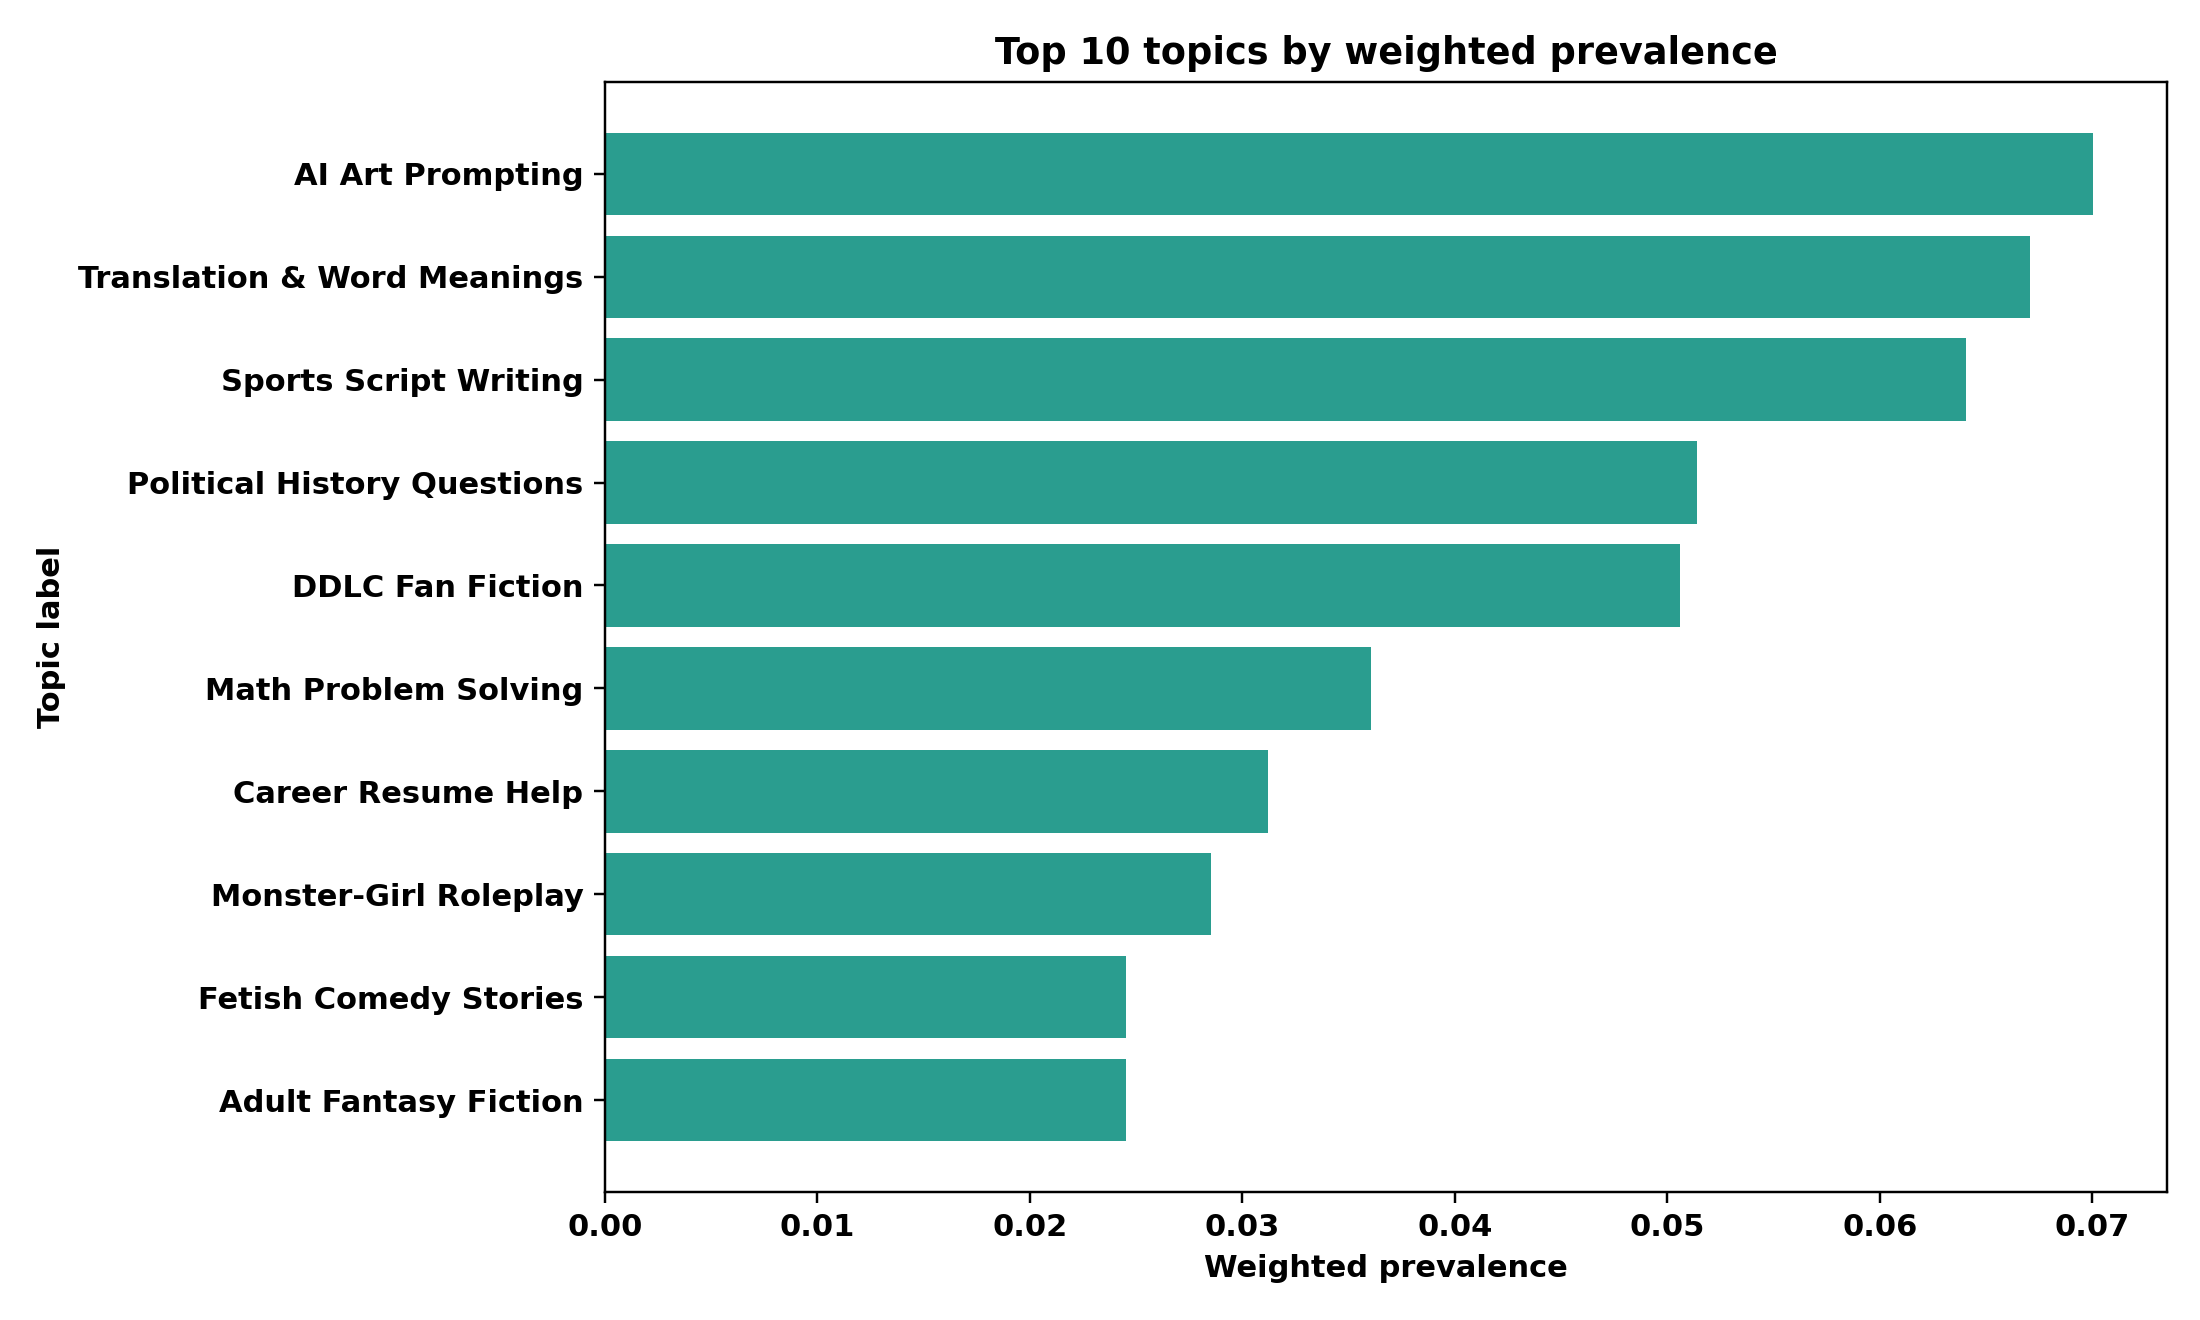

In [2]:
# Top-10 topics by weighted prevalence
display(Image(FIG['labeled'] / 'fig_top10_topic_weighted_prevalence.png', width=850))

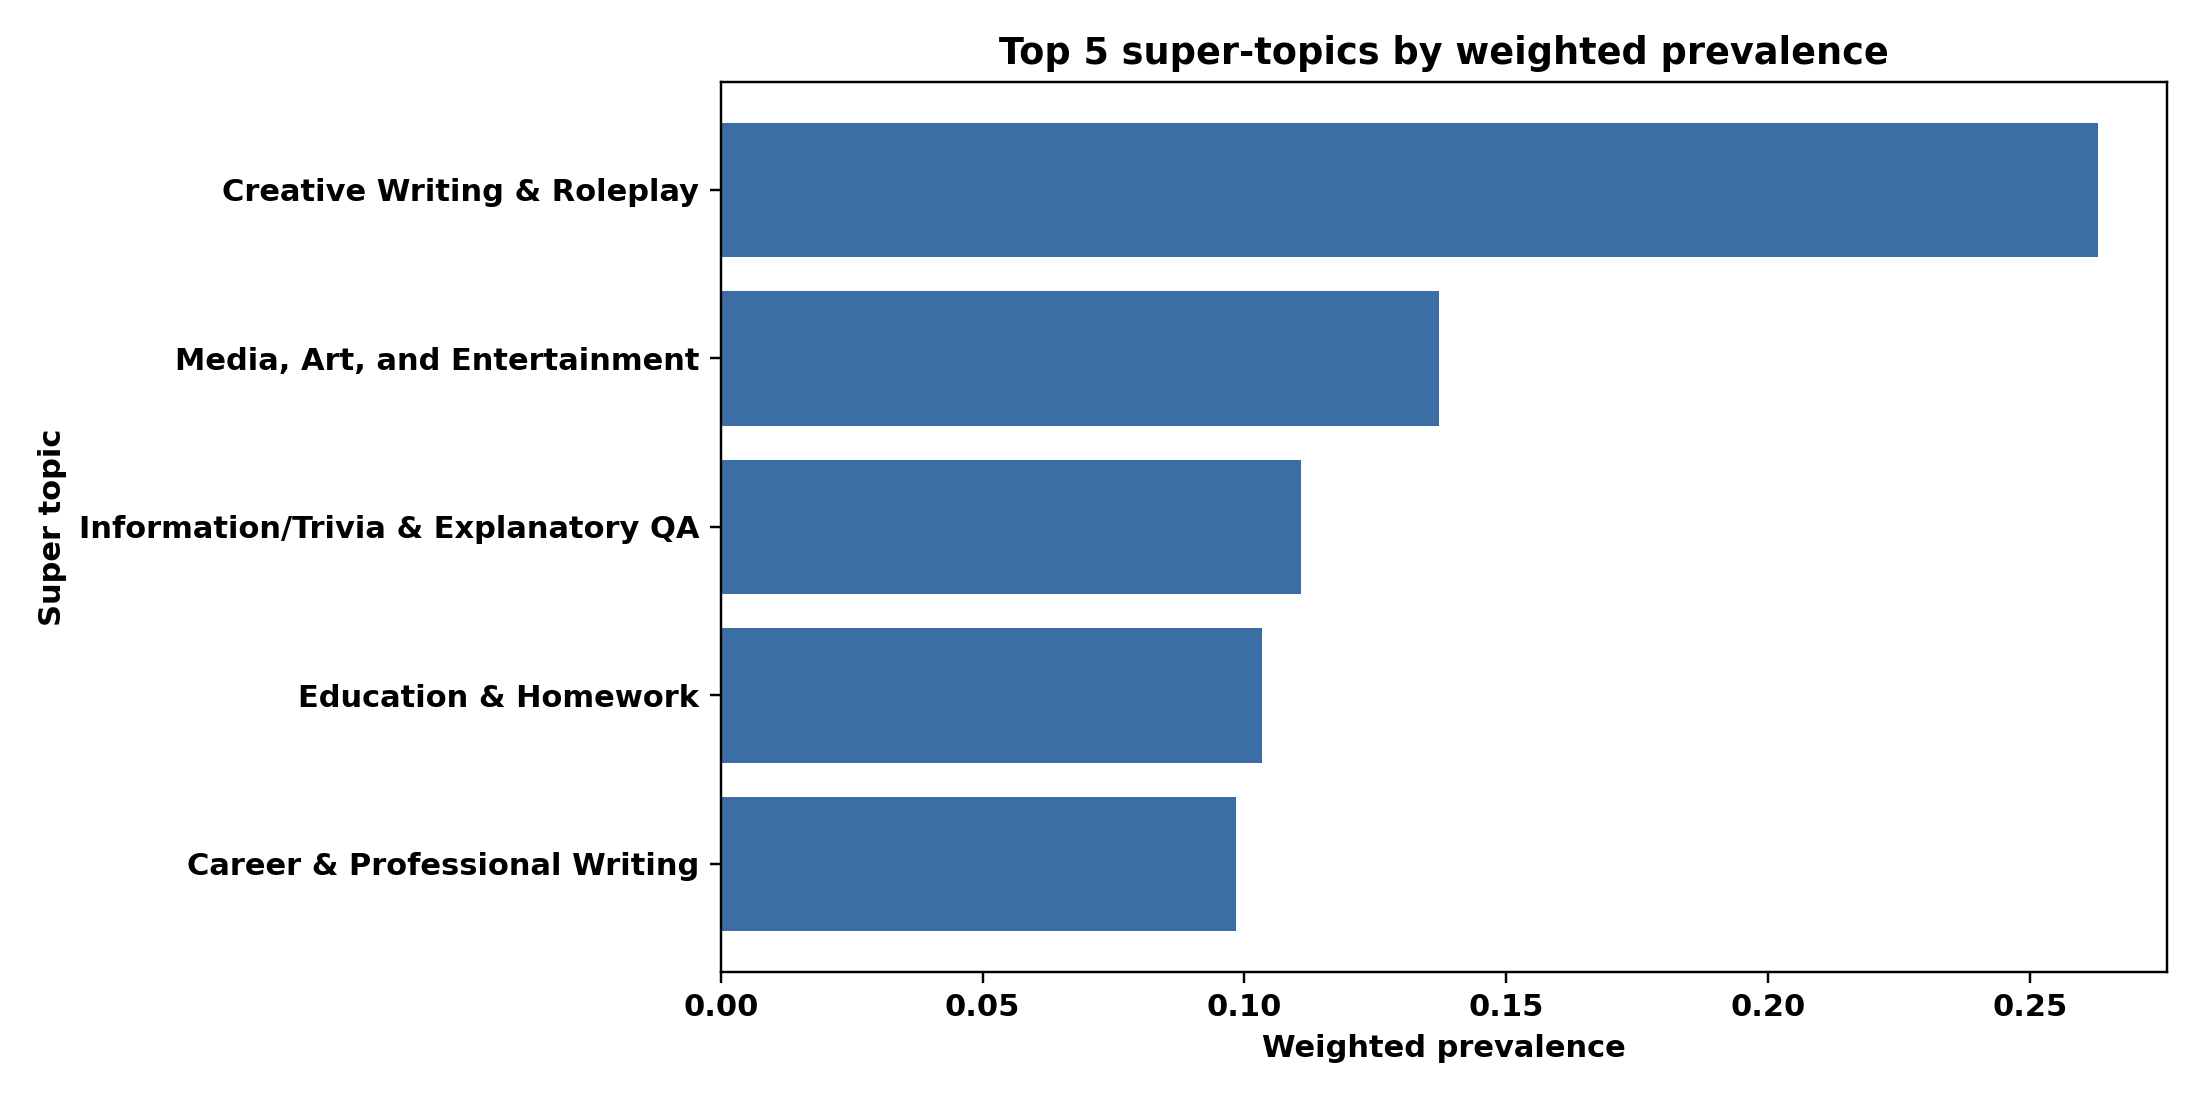

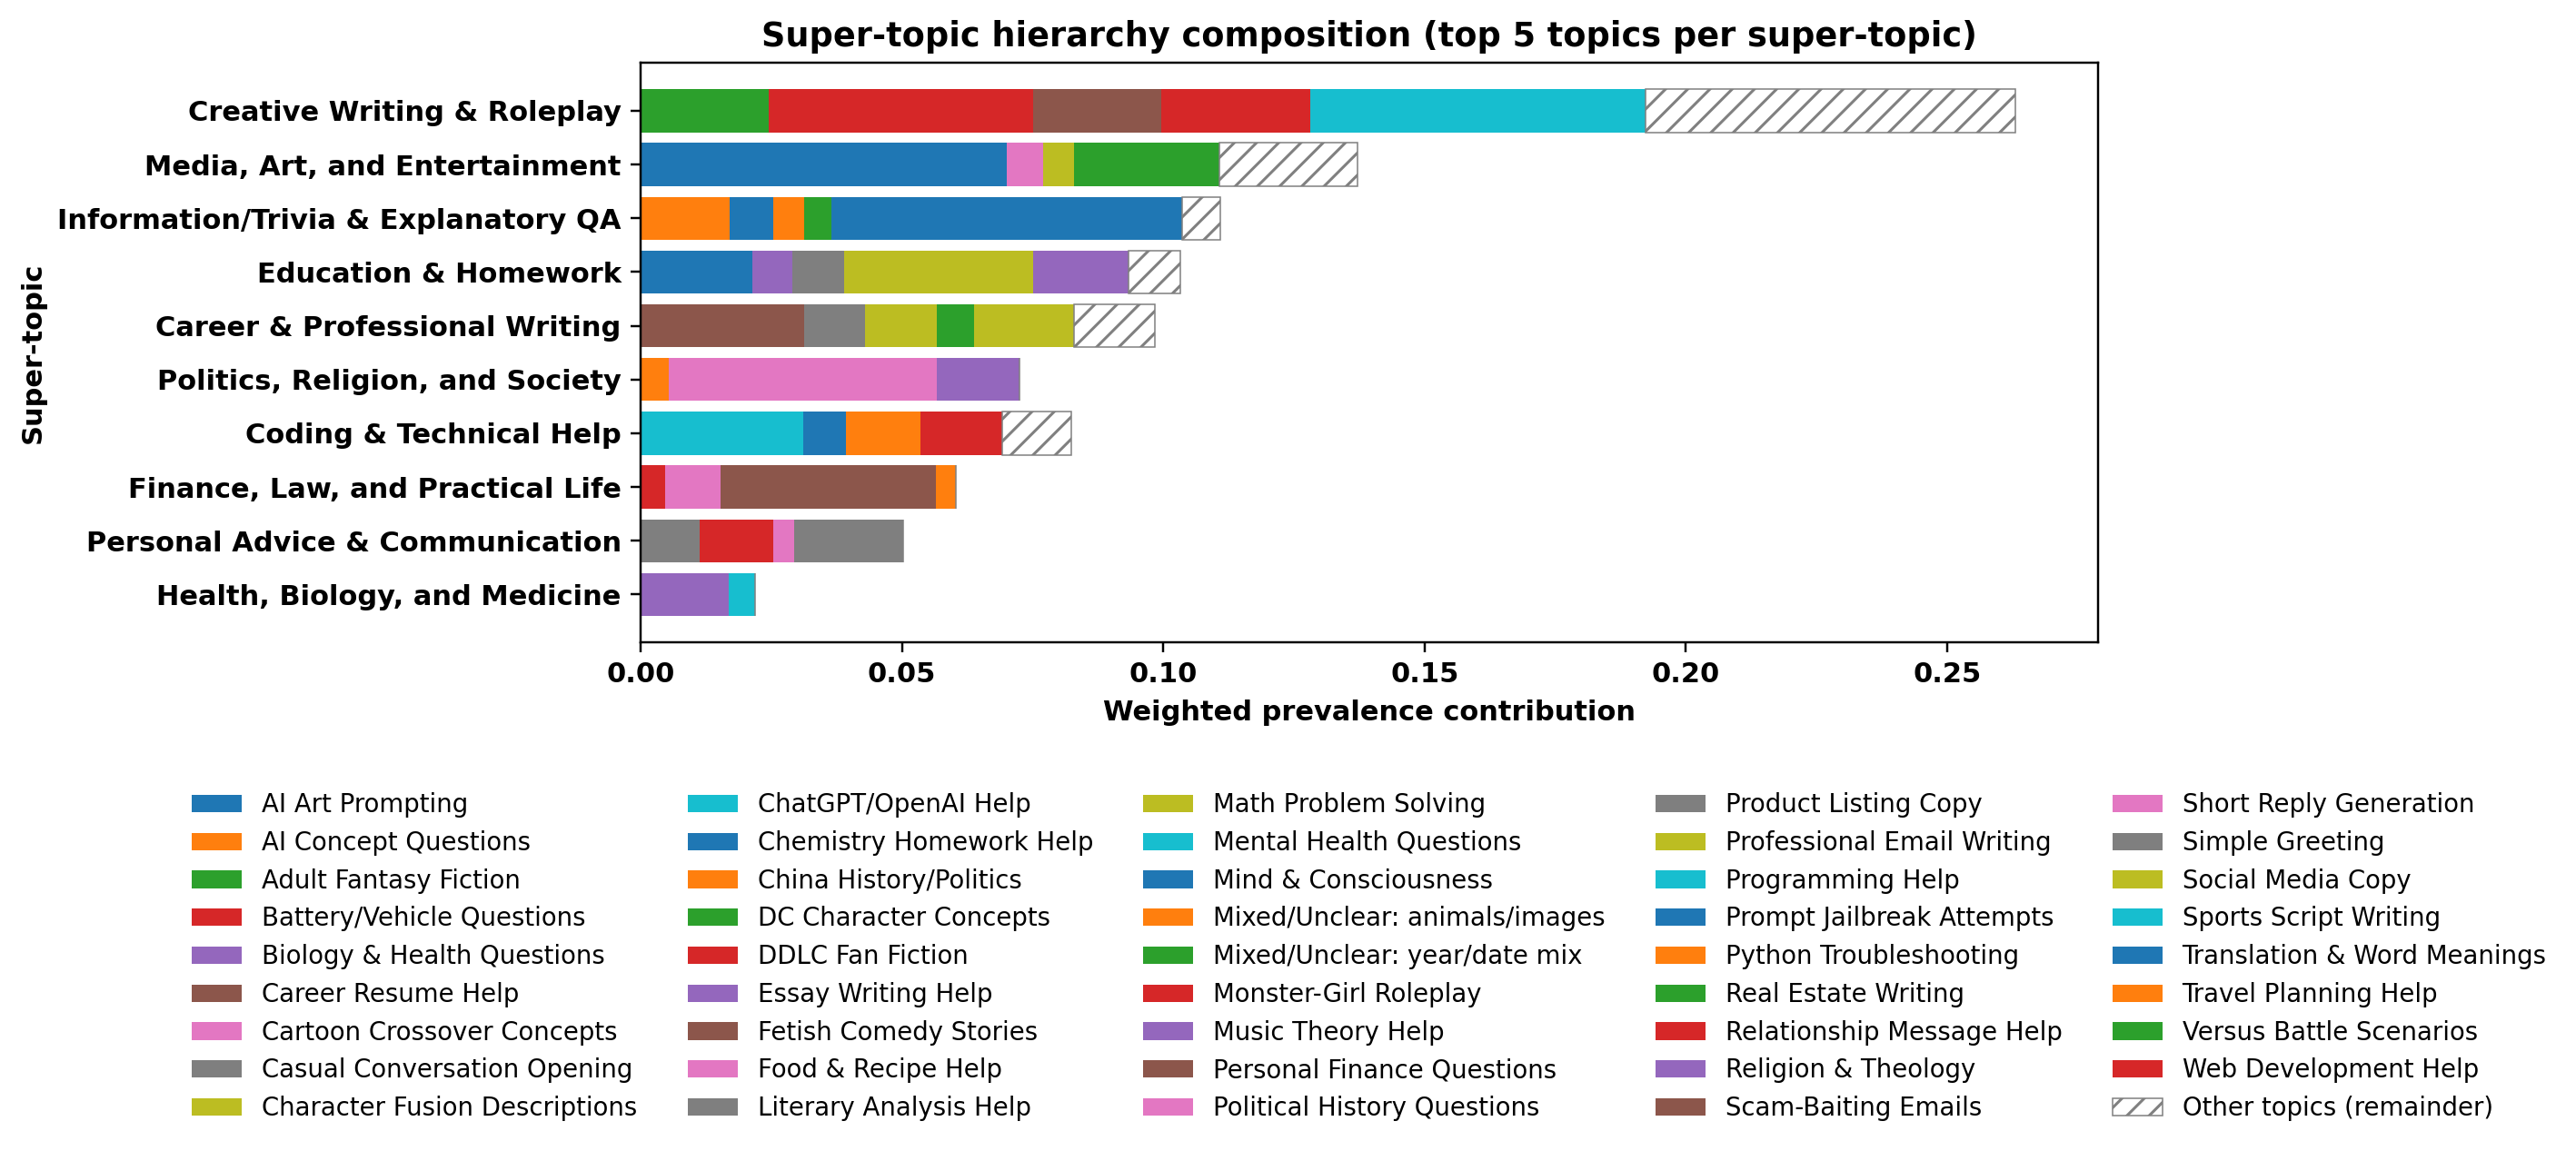

In [3]:
# Top-5 super-topics and full super-topic hierarchy
display(Image(FIG['labeled'] / 'fig_top5_super_topic_weighted_prevalence.png', width=700))
display(Image(FIG['labeled'] / 'fig_super_topic_hierarchy_composition.png', width=900))

**Cross-state topic heterogeneity (§1.3):** All 76 raw BERTopics show significant cross-state dispersion under a **binomial null model** 
(FDR $q = 0.0002$), confirming topic distributions are geographically structured rather than random. 
The null model asks: *if every user drew topics independently at the global rate, would state-level variance be this large?* — for every topic, the answer is no. 
Note that CI-significant topics (tested later for demographic correlation) are not necessarily the highest-dispersion ones: 
many high-dispersion topics have weak demographic correlates, suggesting state differences driven by factors beyond income and education.

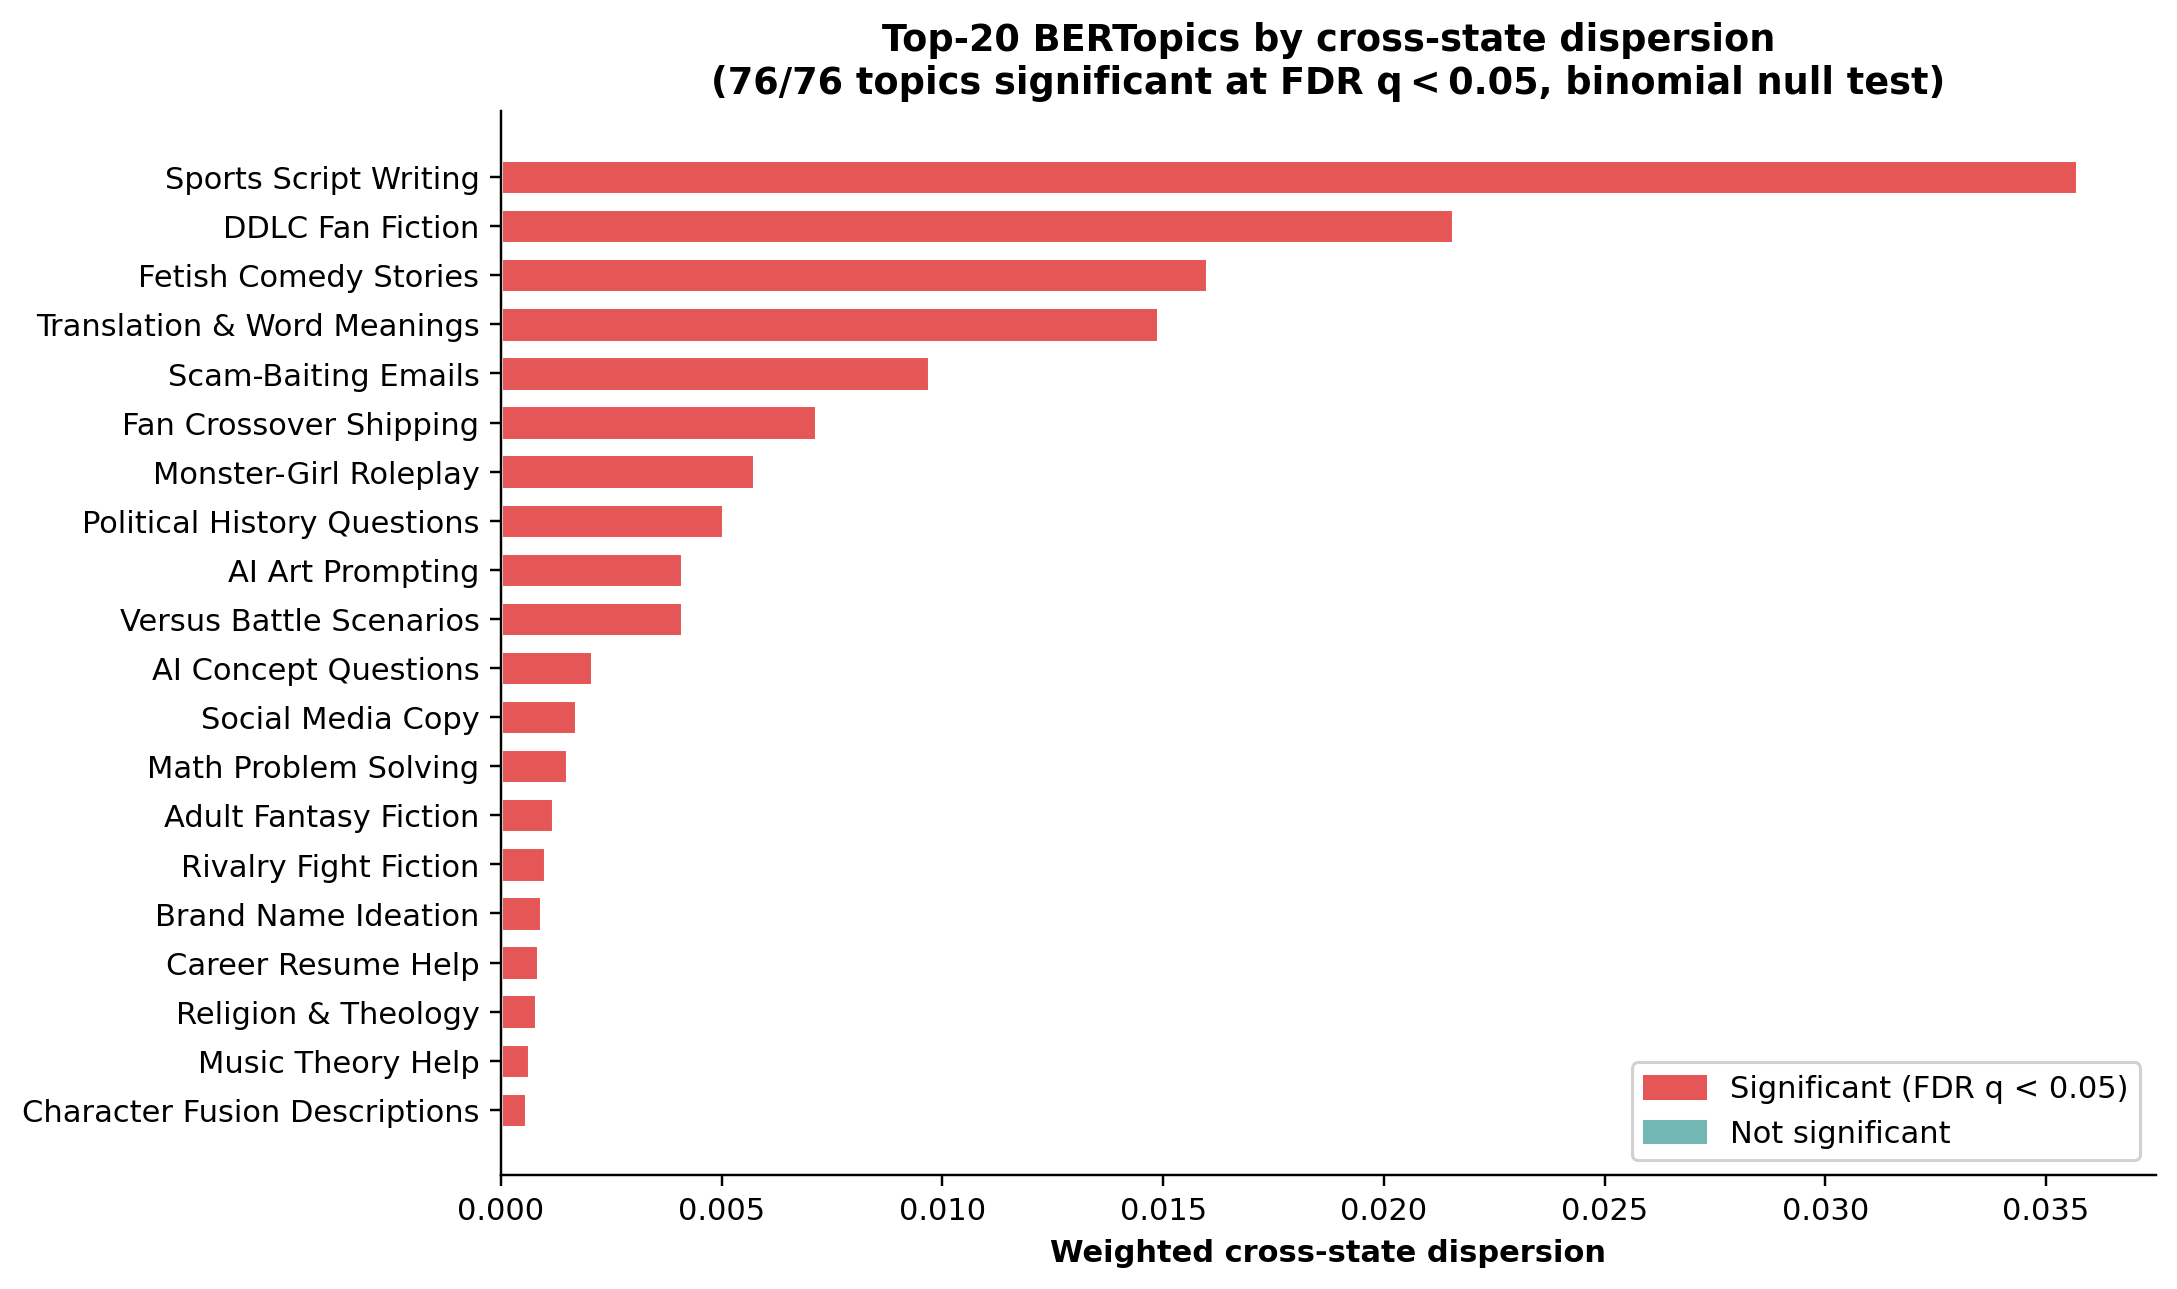

In [4]:
display(Image(FIG['labeled'] / 'fig_cross_state_topic_dispersion.png', width=850))

---
## 2. Demographic Analysis

> Detailed analysis: [topic_demographic_relationship.ipynb](topic_demographic_relationship.ipynb)

Spearman's ρ was computed between each merged topic's state-level proportion and two demographic covariates: **median household income** and **educational attainment** (% bachelor's degree or higher) across 36 US states.

Significance was assessed by **95% bootstrap CI** (primary) and BH-FDR (secondary).

**Key findings:**
- 4 unique merged topics are CI-significant (bootstrap CI excludes 0)
- SCP Creative Writing and Image Generation Requests are significant for *both* covariates
- Most topics show negligible demographic signal (right-skewed |ρ| distribution)

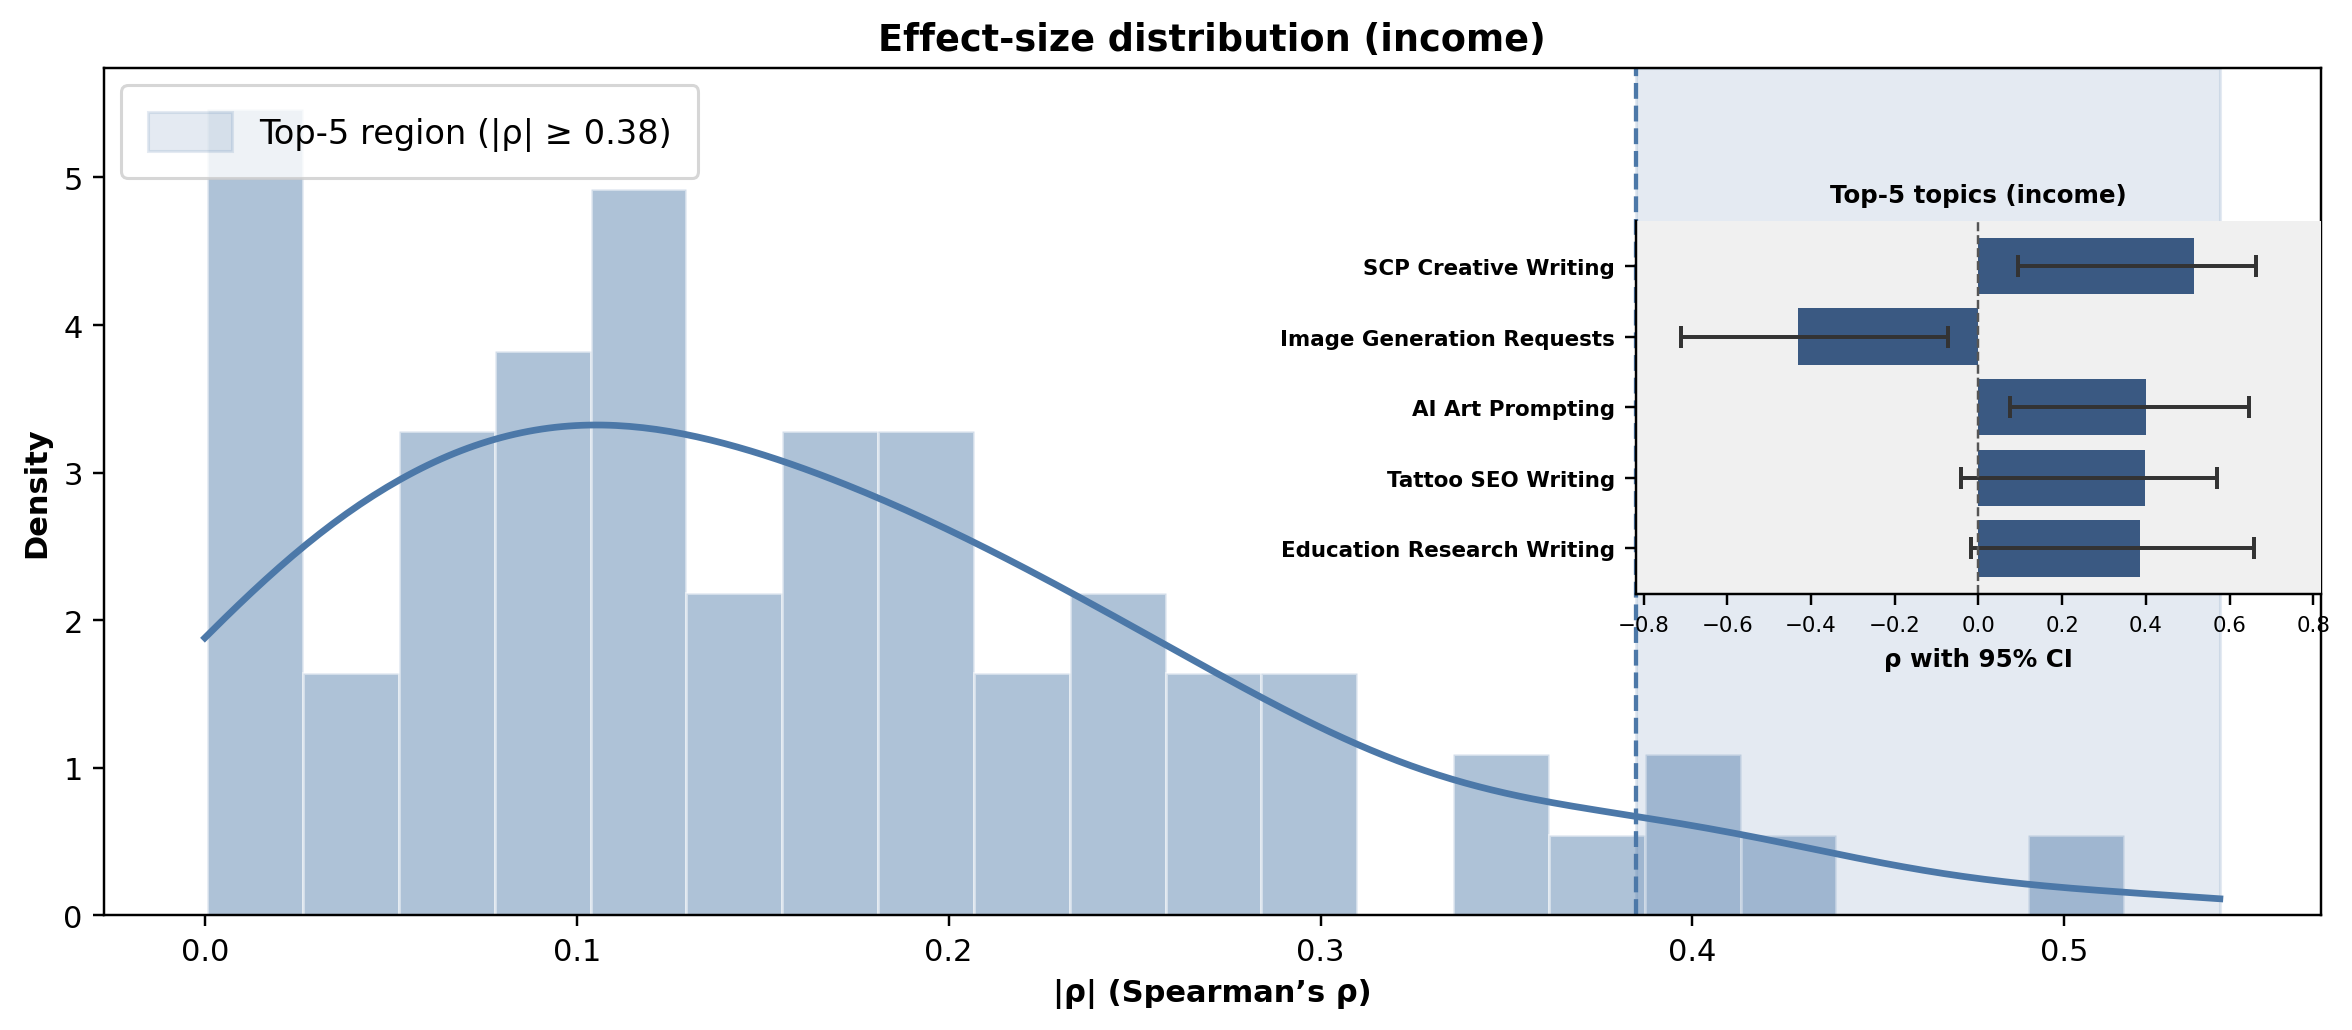

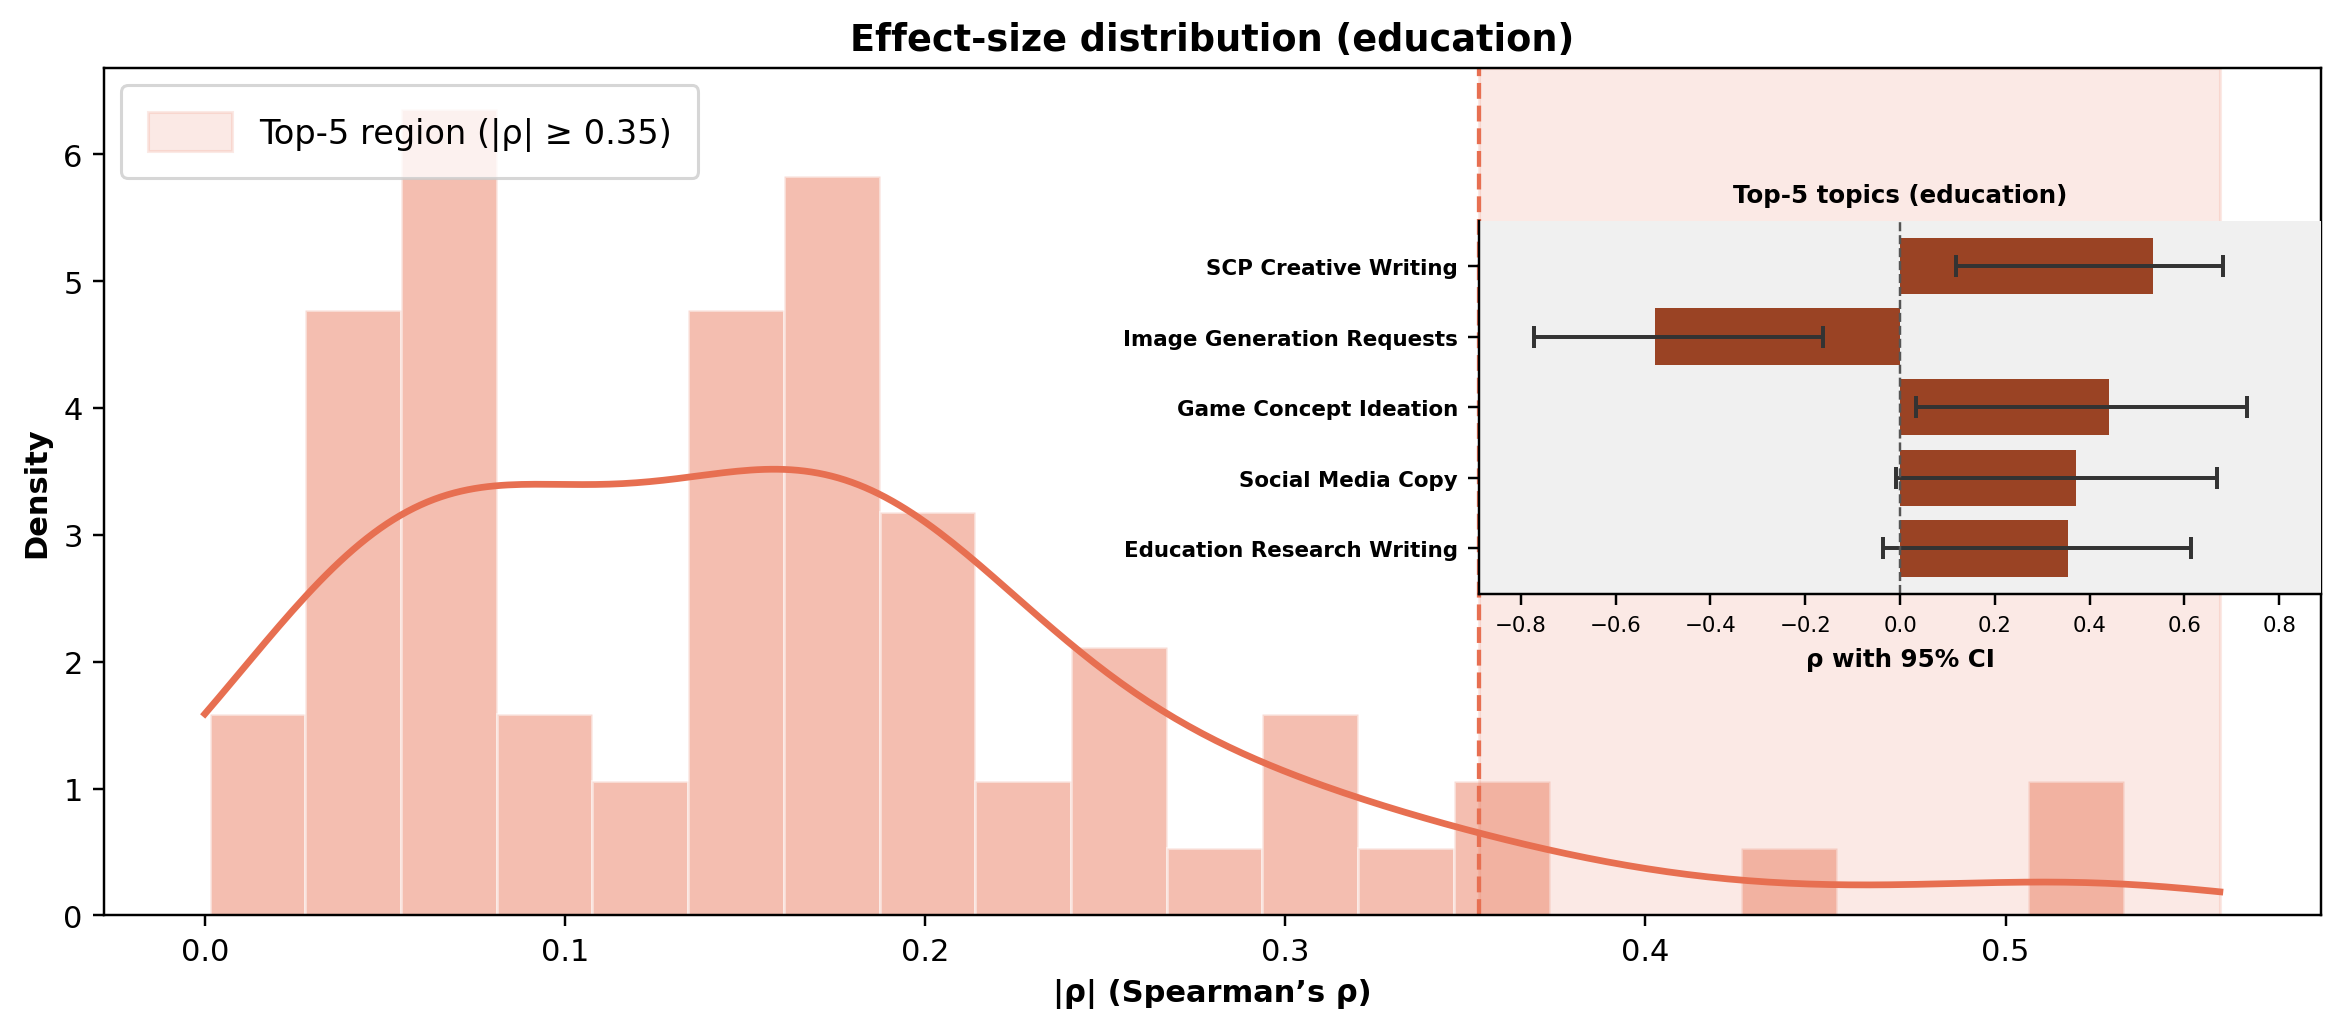

In [5]:
# Effect-size distributions with top-5 insets — income and education
display(Image(FIG['demo'] / 'T1a_income_dist_top5.png', width=850))
display(Image(FIG['demo'] / 'T1b_education_dist_top5.png', width=850))

In [6]:
# CI-significant topics summary table
sp = pd.read_csv(TAB / 'spearman_merged_topic_covariates.csv')
ci_sig = (
    sp[sp['ci_sig']]
    .assign(abs_rho=lambda d: d['spearman_rho'].abs())
    .sort_values(['covariate', 'abs_rho'], ascending=[True, False])
    [['covariate', 'topic_label', 'super_topic', 'spearman_rho', 'ci_low', 'ci_high', 'fdr_q_value']]
    .reset_index(drop=True)
)
ci_sig.columns = ['Covariate', 'Topic', 'Super-topic', 'ρ', 'CI low', 'CI high', 'FDR q']
display(ci_sig.style.format({'ρ': '{:.3f}', 'CI low': '{:.3f}', 'CI high': '{:.3f}', 'FDR q': '{:.3f}'}))

,Covariate,Topic,Super-topic,ρ,CI low,CI high,FDR q
0,education,SCP Creative Writing,Creative Writing & Roleplay,0.533,0.118,0.682,0.043
1,education,Image Generation Requests,"Media, Art, and Entertainment",-0.518,-0.771,-0.163,0.043
2,education,Game Concept Ideation,"Media, Art, and Entertainment",0.440,0.034,0.731,0.172
3,income,SCP Creative Writing,Creative Writing & Roleplay,0.516,0.094,0.664,0.091
4,income,Image Generation Requests,"Media, Art, and Entertainment",-0.430,-0.711,-0.073,0.284
5,income,AI Art Prompting,"Media, Art, and Entertainment",0.400,0.076,0.646,0.284


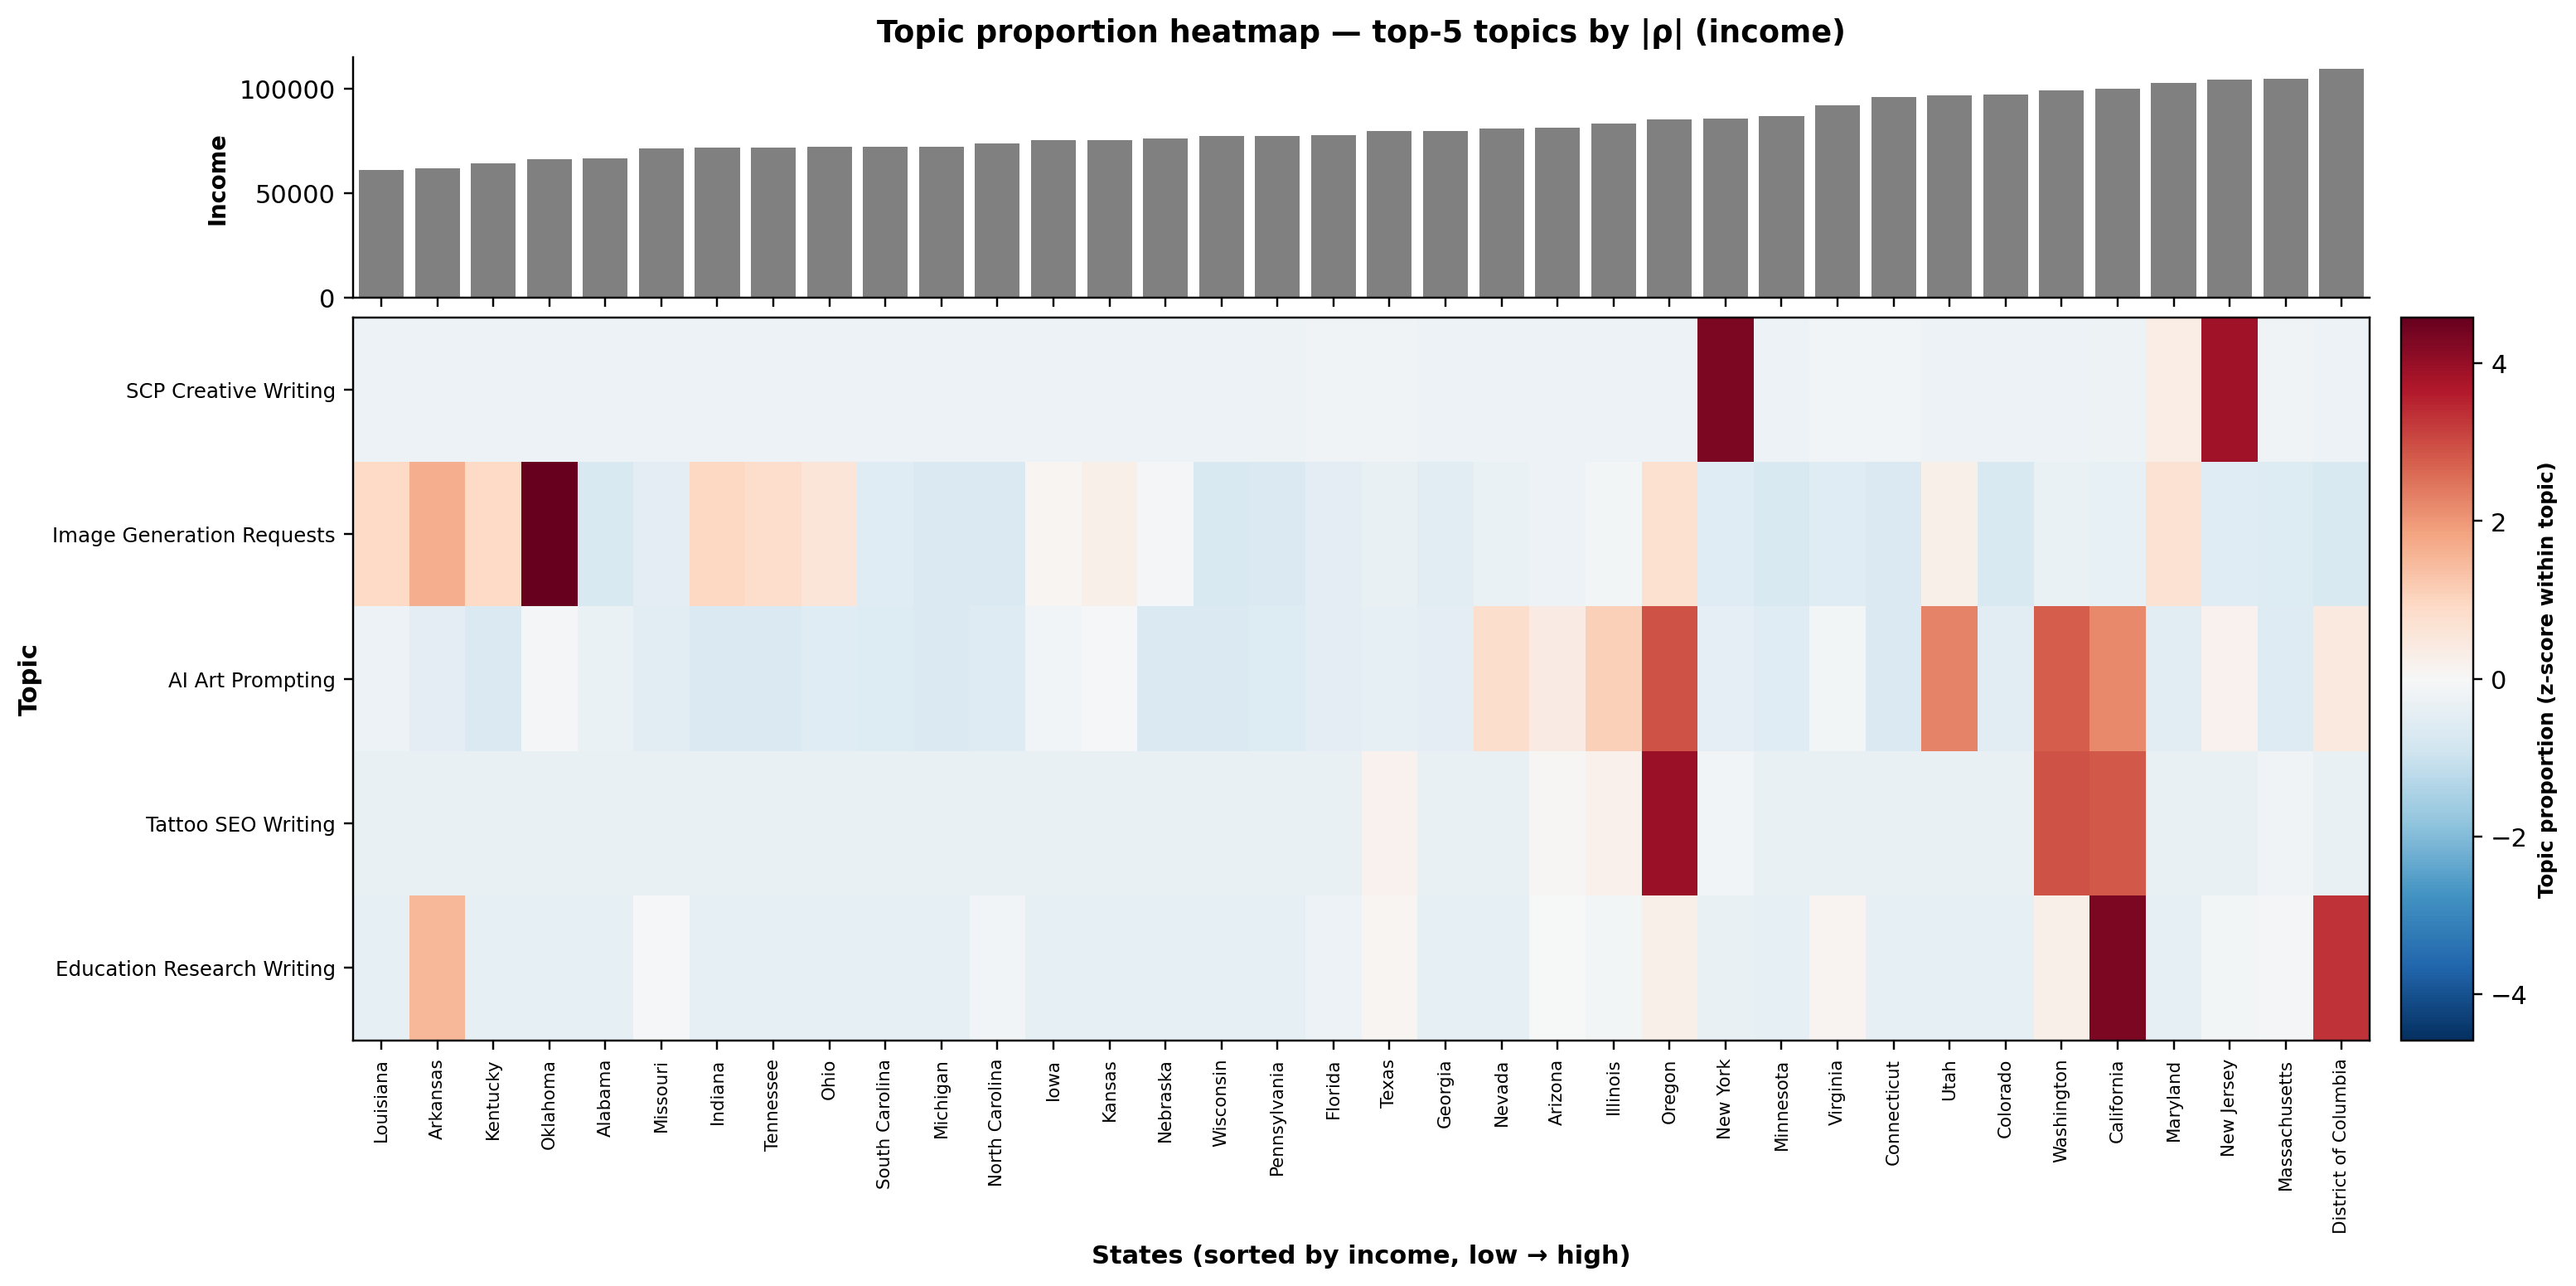

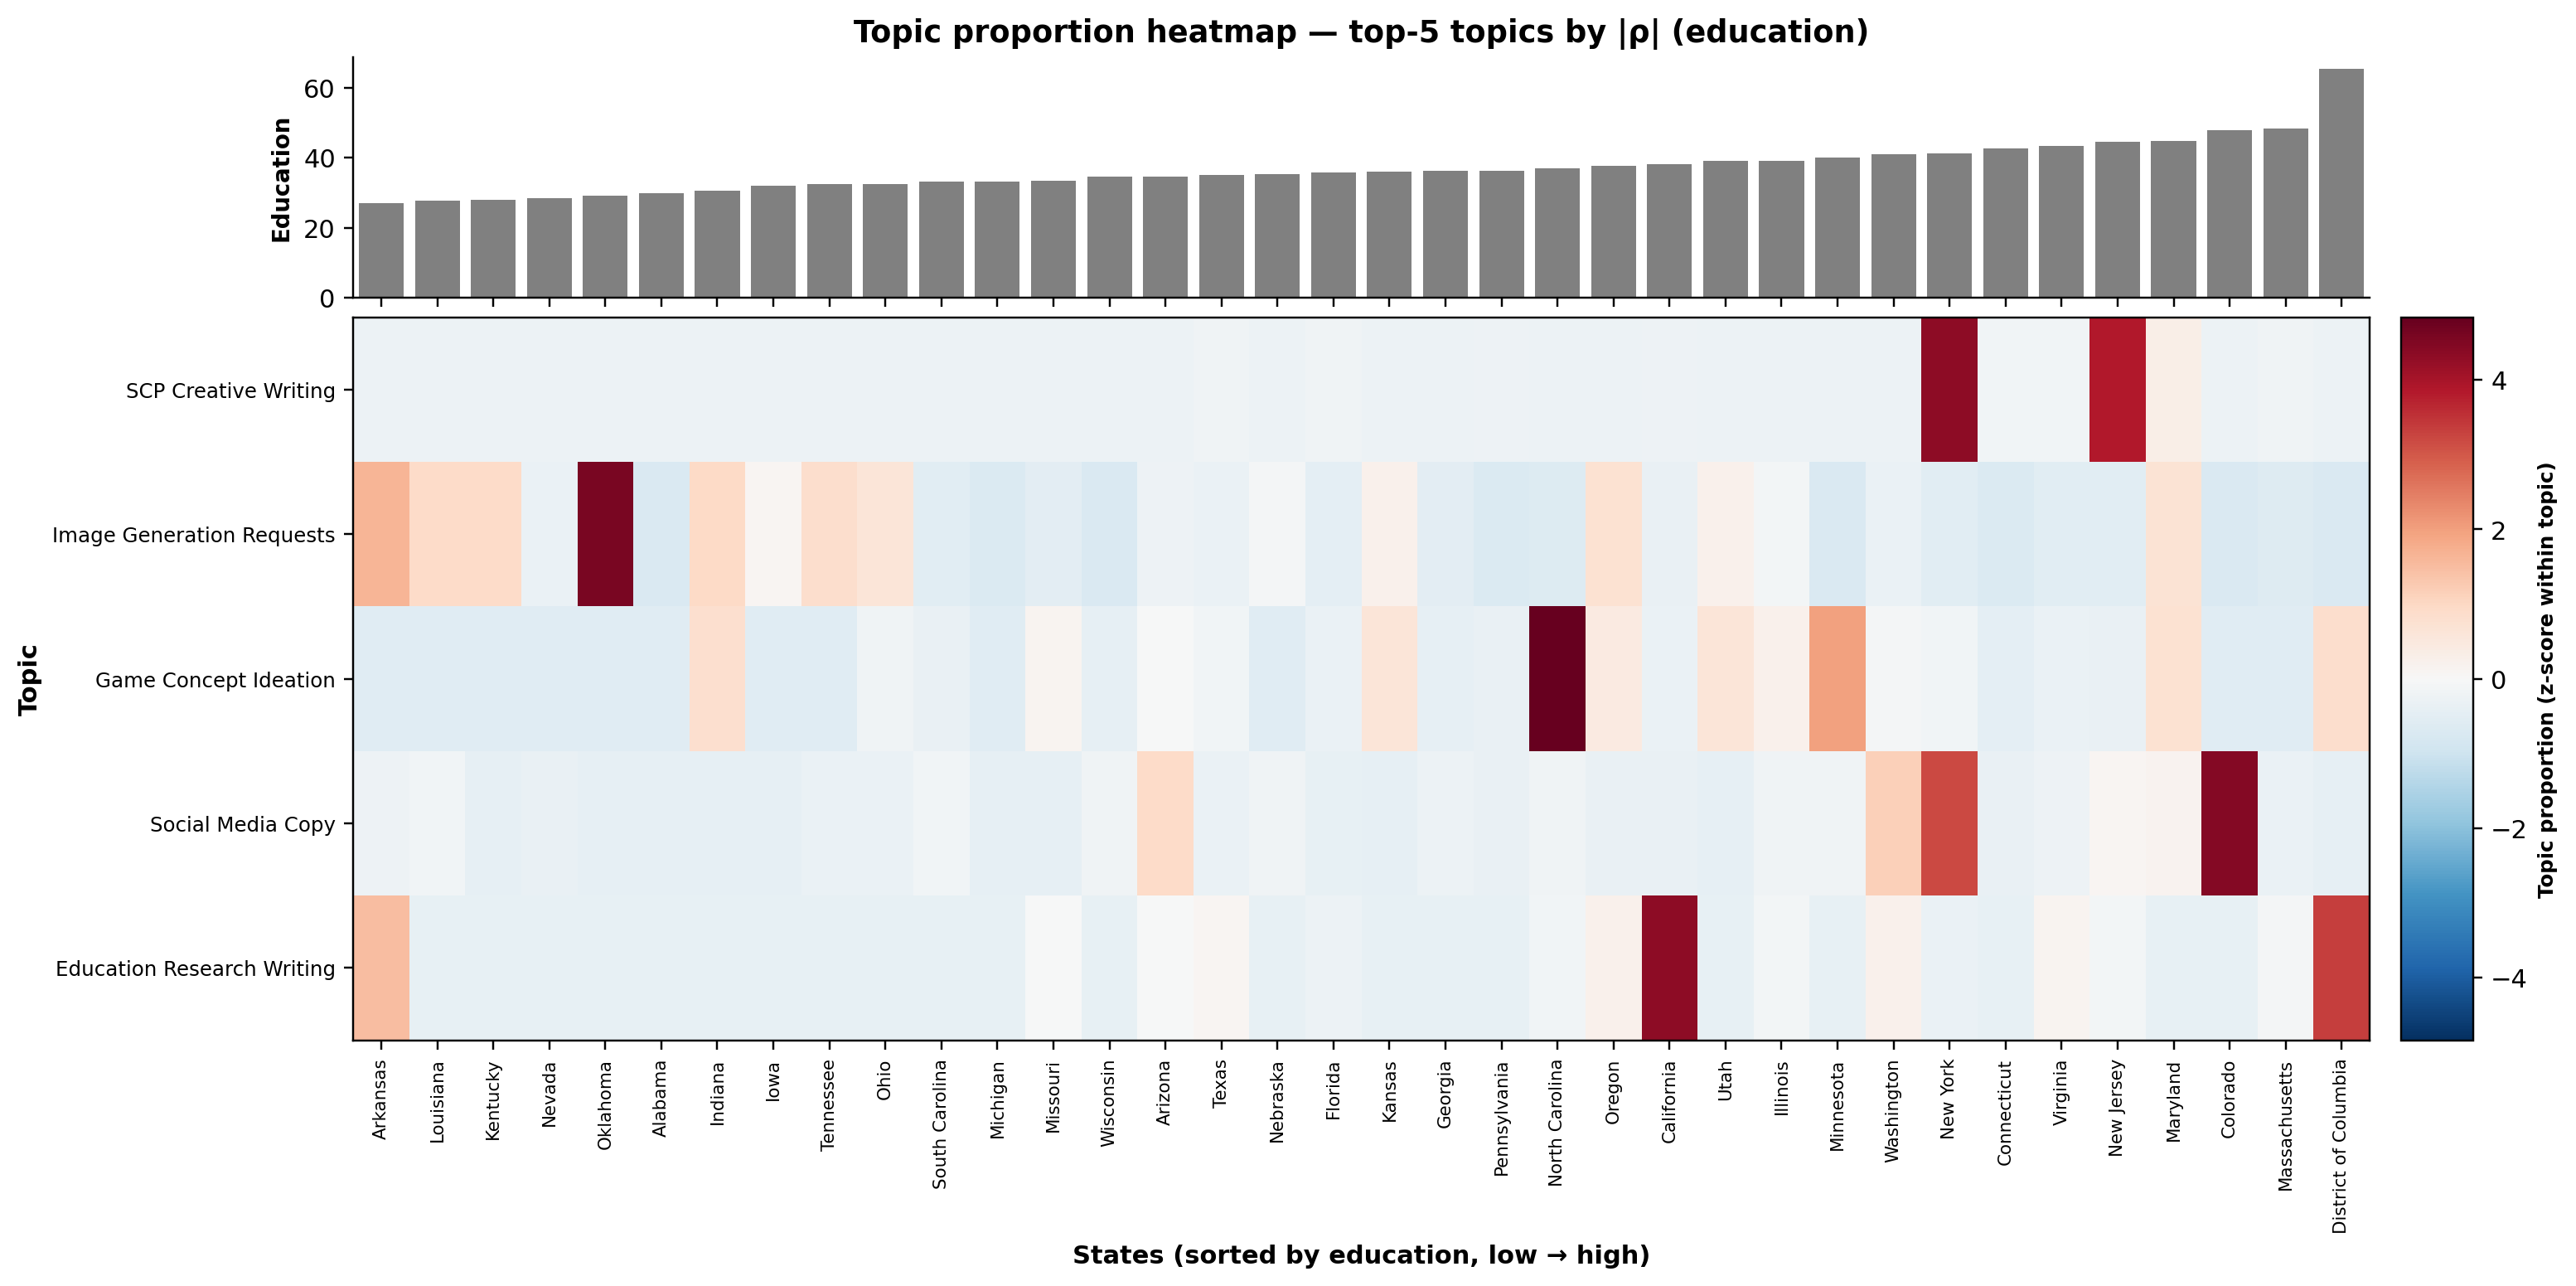

In [7]:
# z-scored topic proportion heatmaps — states sorted by covariate level
display(Image(FIG['demo'] / 'heatmap_income_top5_topics.png', width=850))
display(Image(FIG['demo'] / 'heatmap_education_top5_topics.png', width=850))

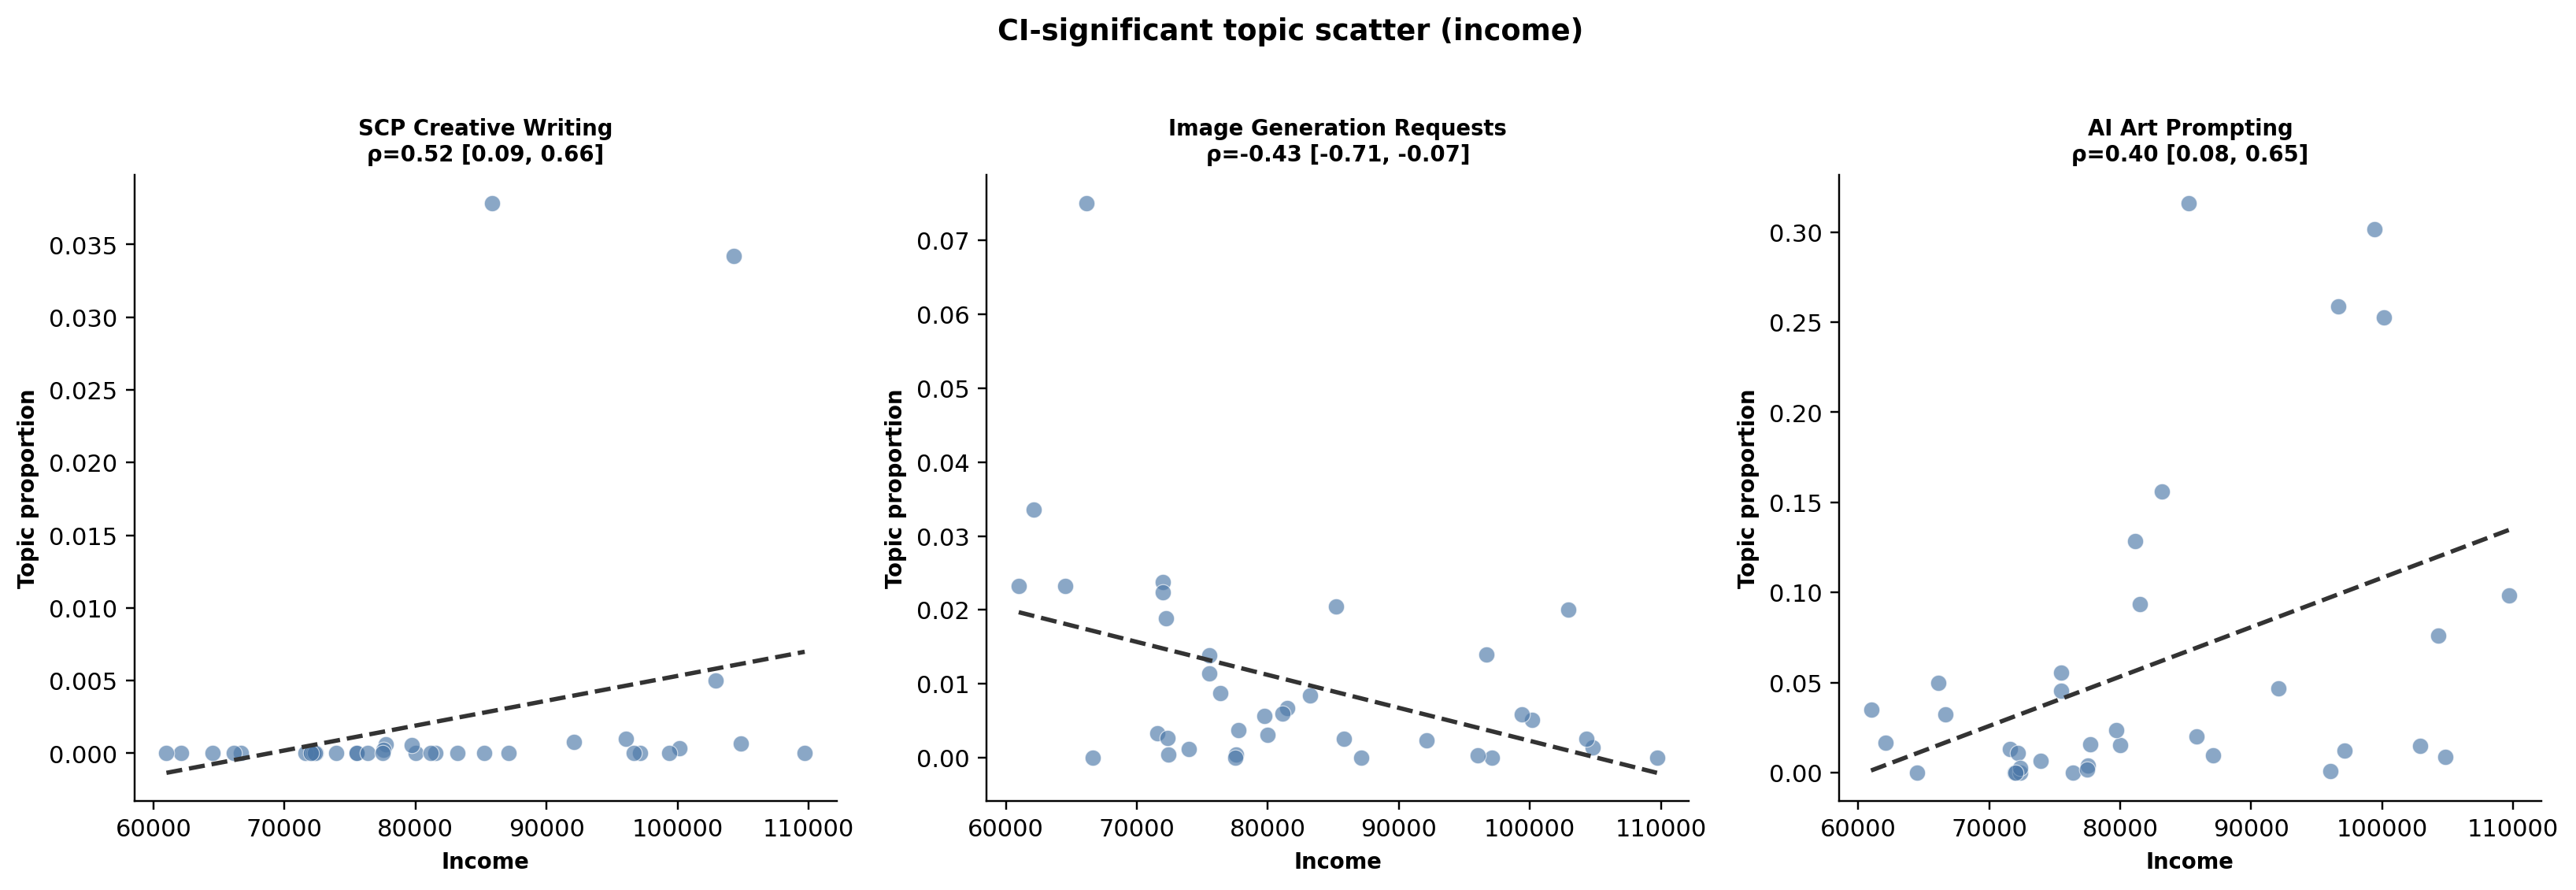

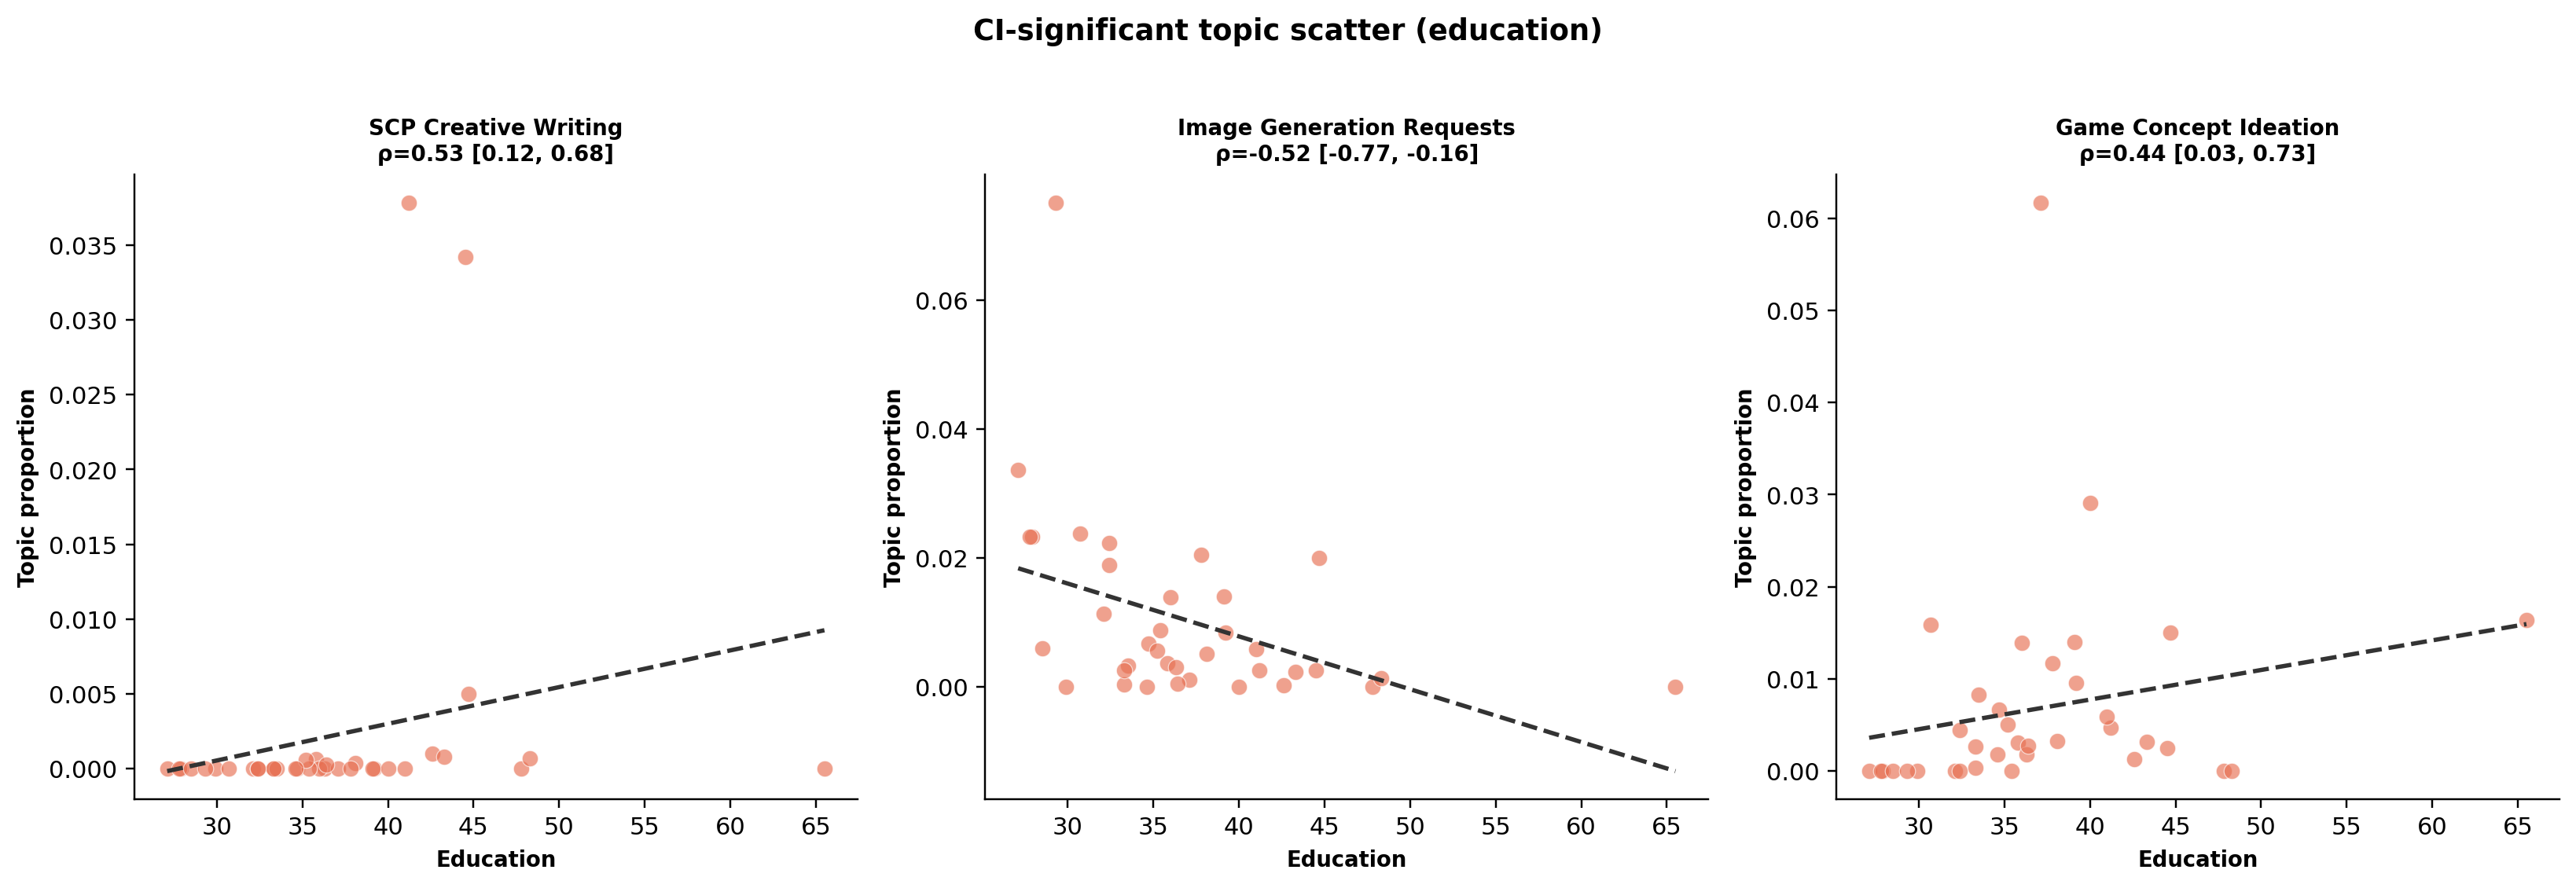

In [8]:
# CI-significant topic scatter with OLS regression lines
display(Image(FIG['demo'] / 'T4a_income_scatter.png', width=850))
display(Image(FIG['demo'] / 'T4b_education_scatter.png', width=850))

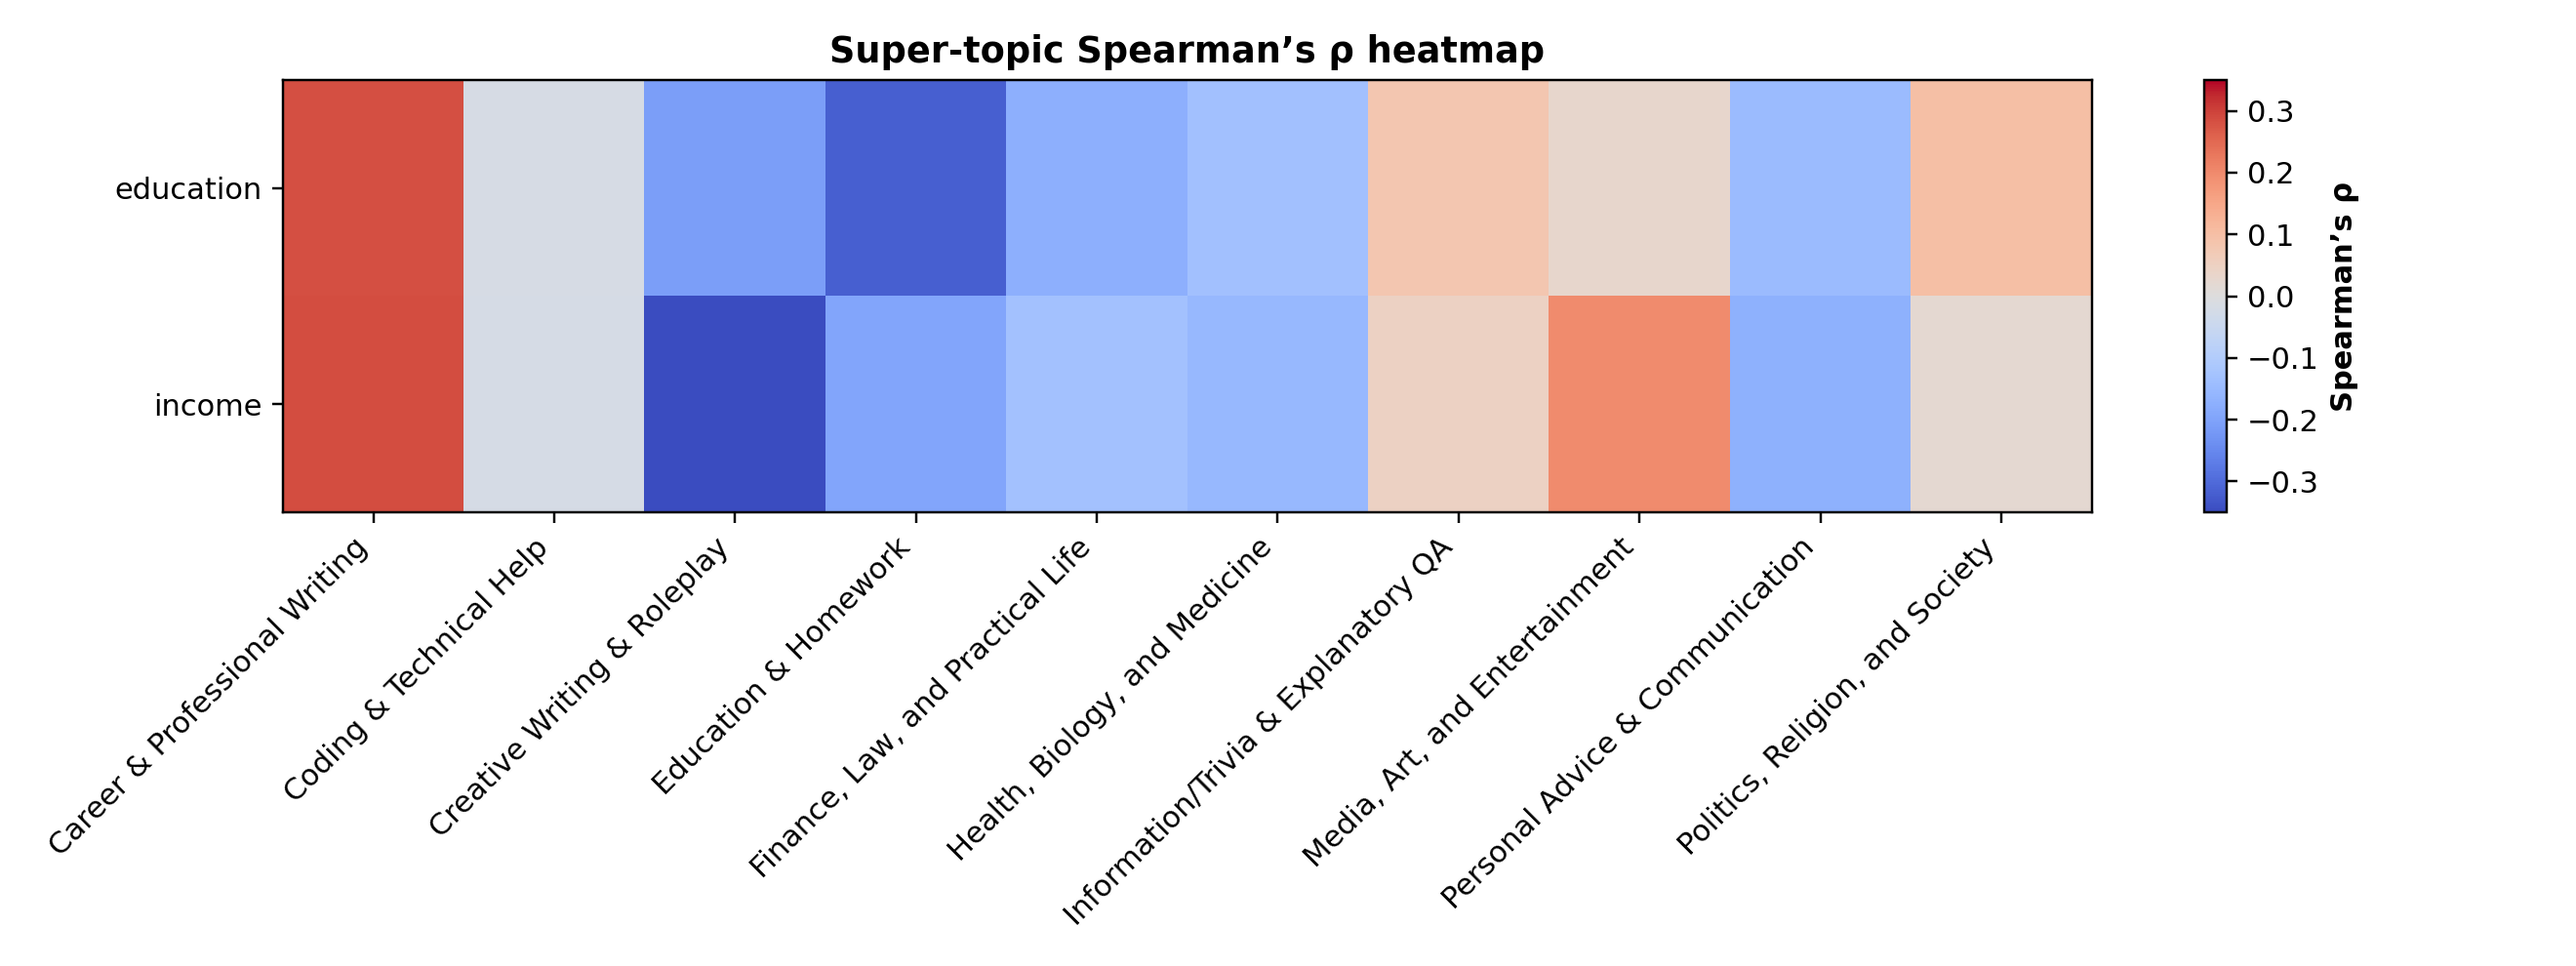

In [9]:
# Super-topic Spearman's ρ heatmap — category-level overview
display(Image(FIG['demo'] / 'U1_super_topic_rho_heatmap.png', width=900))

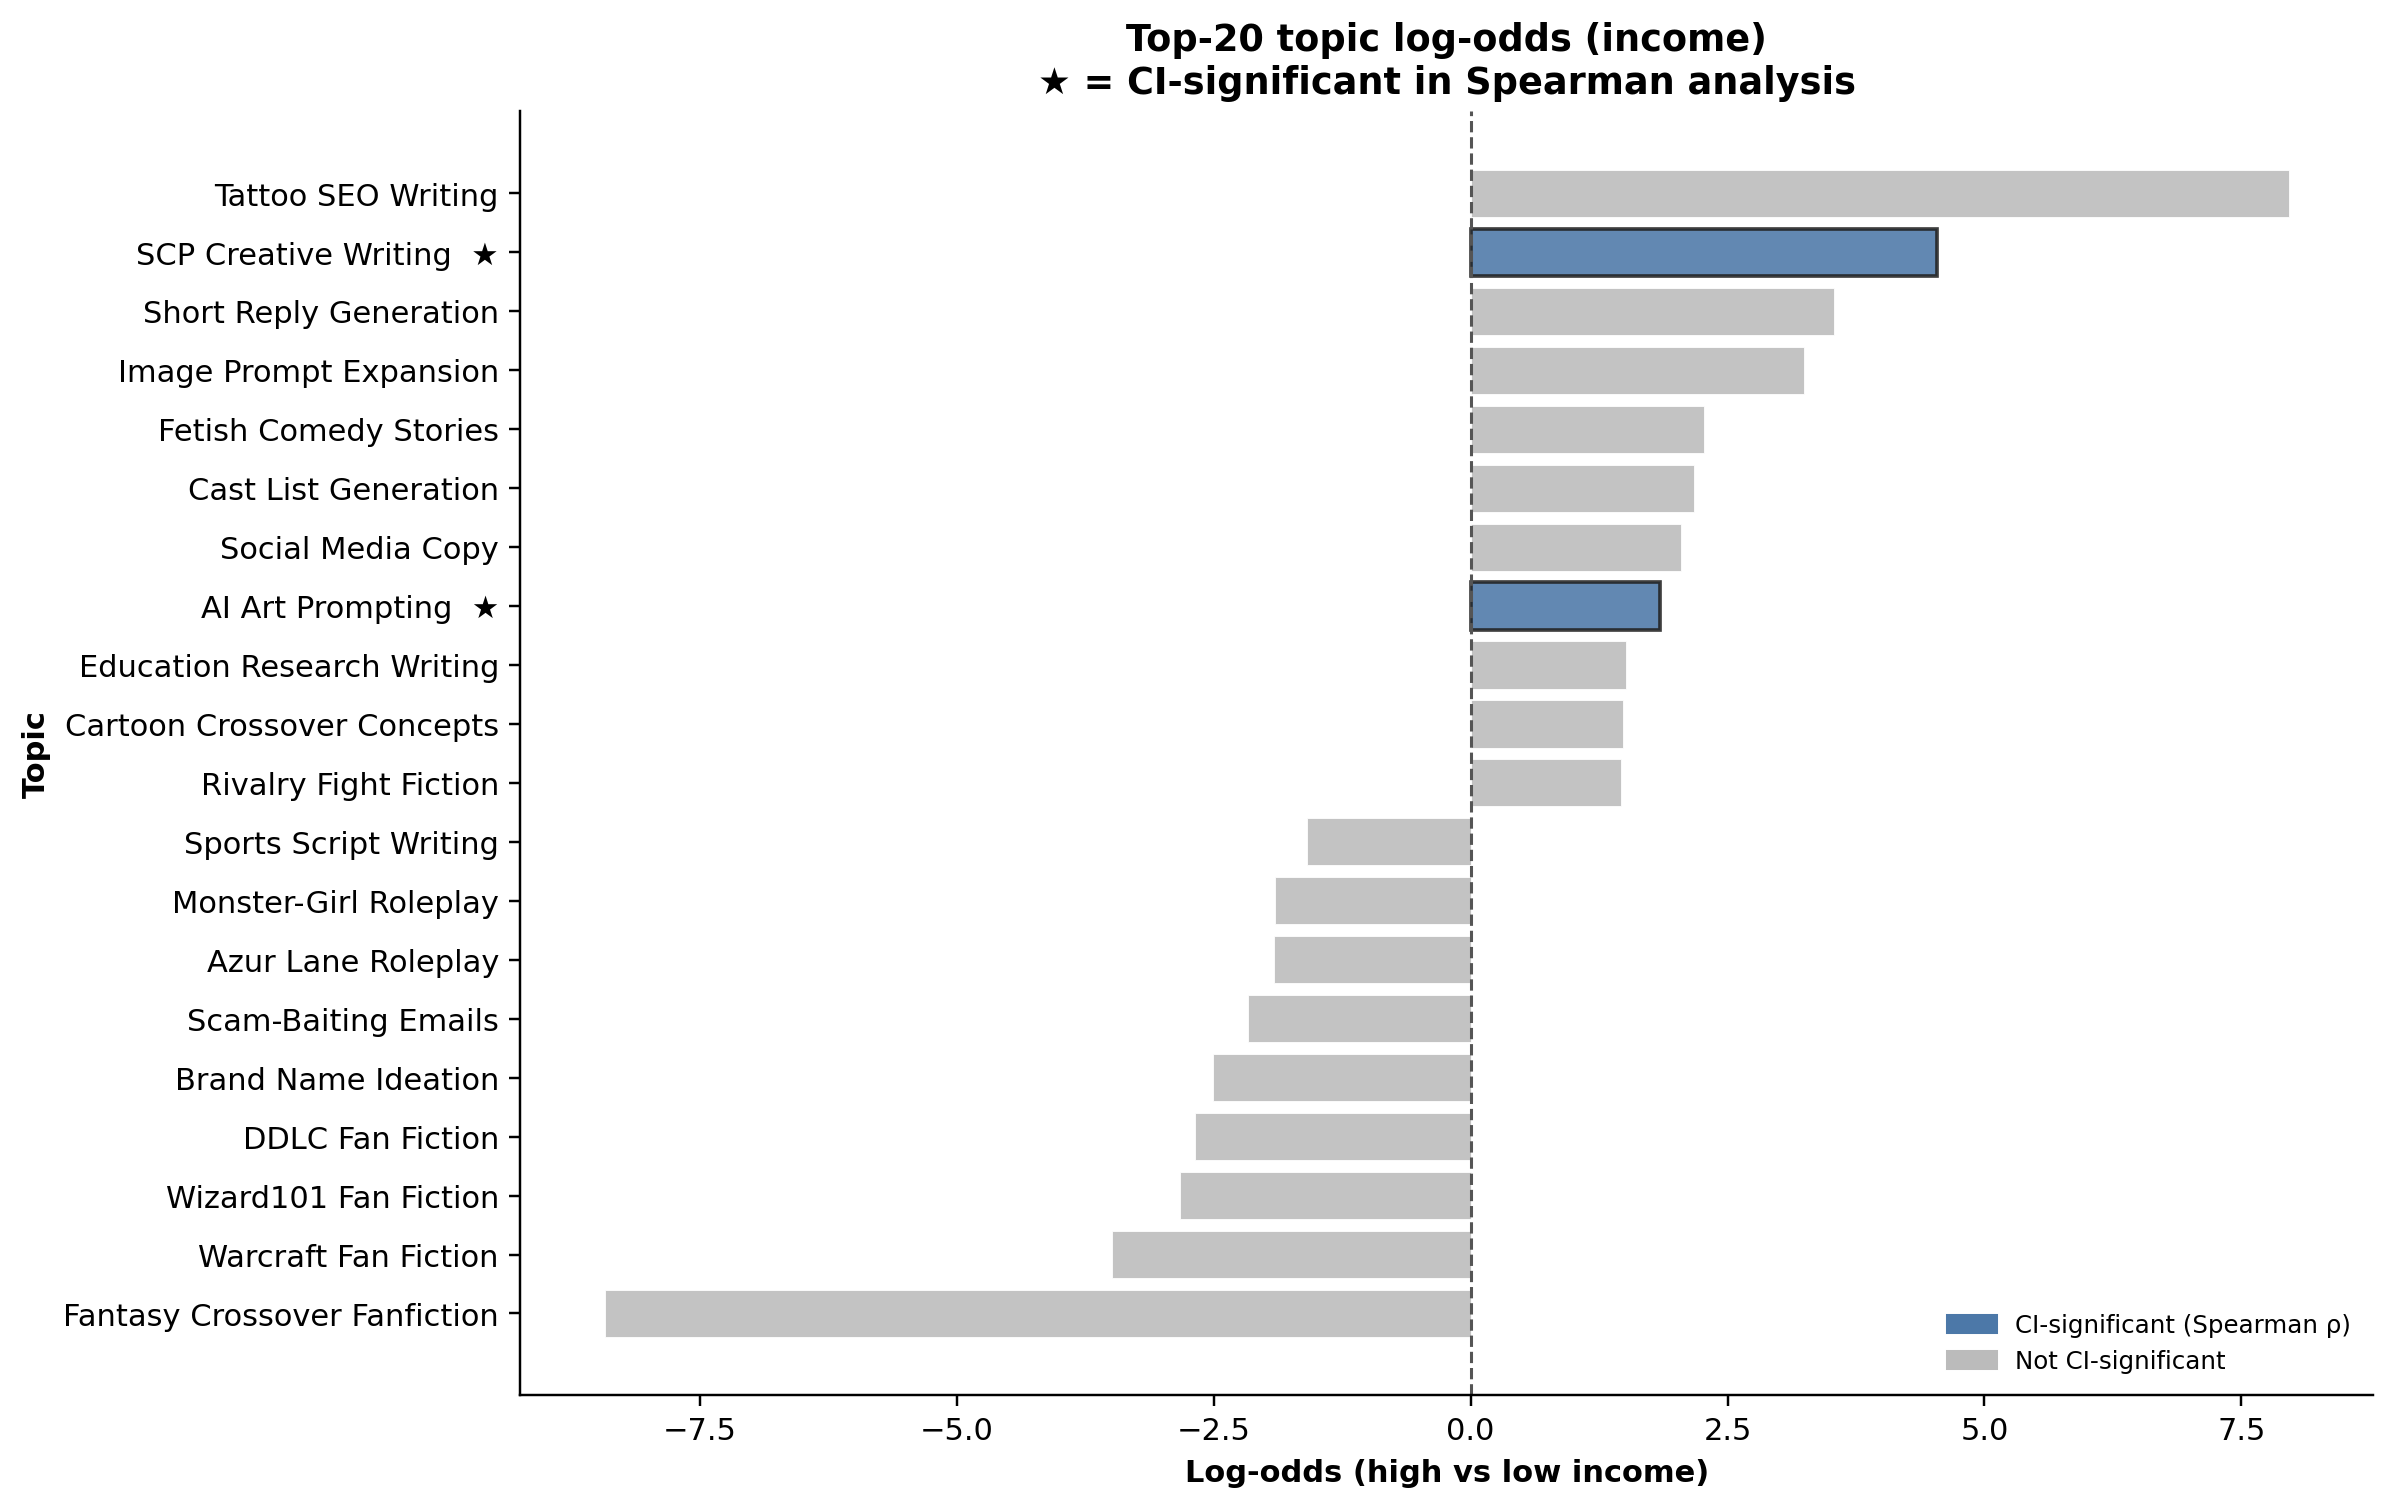

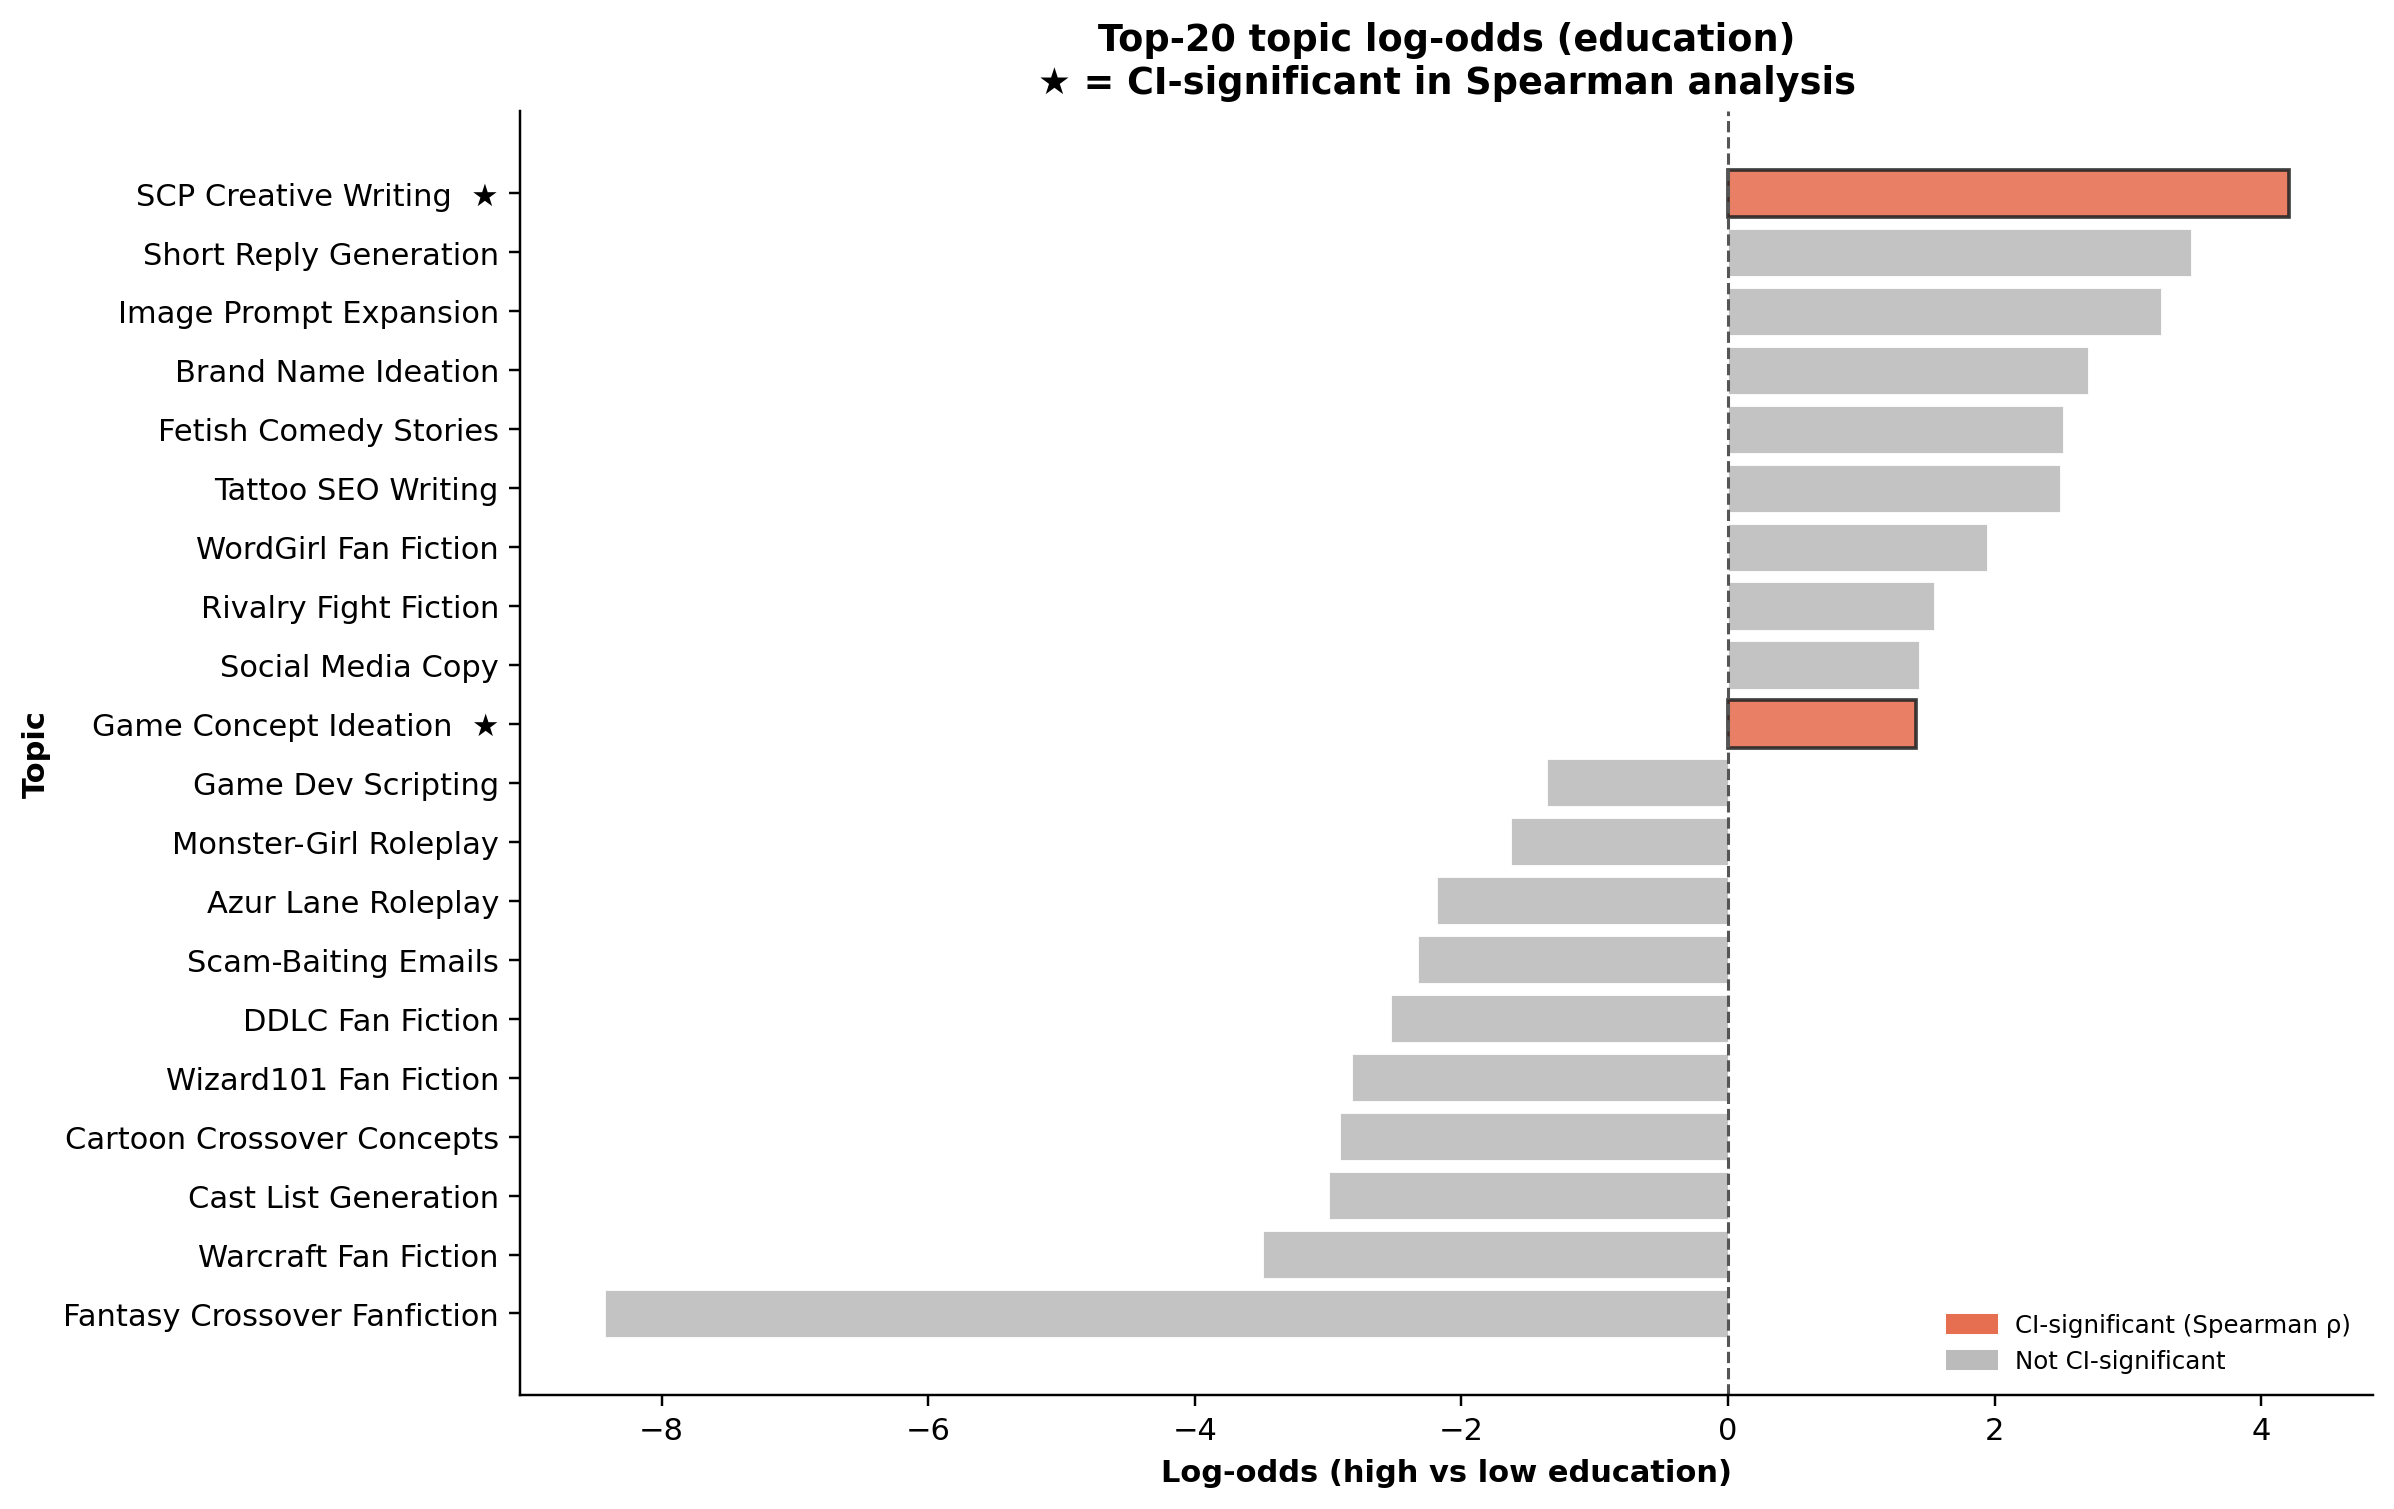

In [10]:
# Supplementary: log-odds cross-validation (income and education)
display(Image(FIG['demo'] / 'log_odds_income.png', width=850))
display(Image(FIG['demo'] / 'log_odds_education.png', width=850))

**Conclusion:** A consistent subset of topics — SCP Creative Writing, Image Generation Requests, AI Art Prompting, and Game Concept Ideation — shows reliable demographic signal confirmed by both Spearman bootstrap CI and log-odds cross-validation. Higher-income and more-educated states use AI assistants more for creative niche tasks (SCP lore, image prompting) and less for image generation requests, while the pattern reverses for lower-income states.

---
## 3. CTM Robustness Check

> Detailed analysis: [CTM_robustness.ipynb](CTM_robustness.ipynb)

CombinedTM (CTM) was trained on the same corpus with 76 topics as an independent check on the BERTopic findings. Best-match Jaccard similarity was computed between each merged BERTopic topic and all 76 CTM topics.

**Metrics used for model comparison:**
- **Topic Coherence (c_v)**: NPMI-based score measuring how often a topic's top words co-occur in actual documents. Higher = more semantically meaningful topics.
- **Topic Diversity**: fraction of unique words across all topics' top-word lists (`unique / total`). Higher = less redundancy between topics.

**Key findings:**
- BERTopic outperforms CTM on both metrics (coherence 0.58 vs 0.48; diversity 0.84 vs 0.61)
- All 4 CI-significant BERTopic topics score ≤ 0.059 Jaccard — effectively zero meaningful alignment
- Non-significant topics reach up to Jaccard 0.50, showing CTM can match generic topics
- This reflects a CTM quality limitation (restricted vocabulary, degenerate topics) rather than contradicting the BERTopic findings


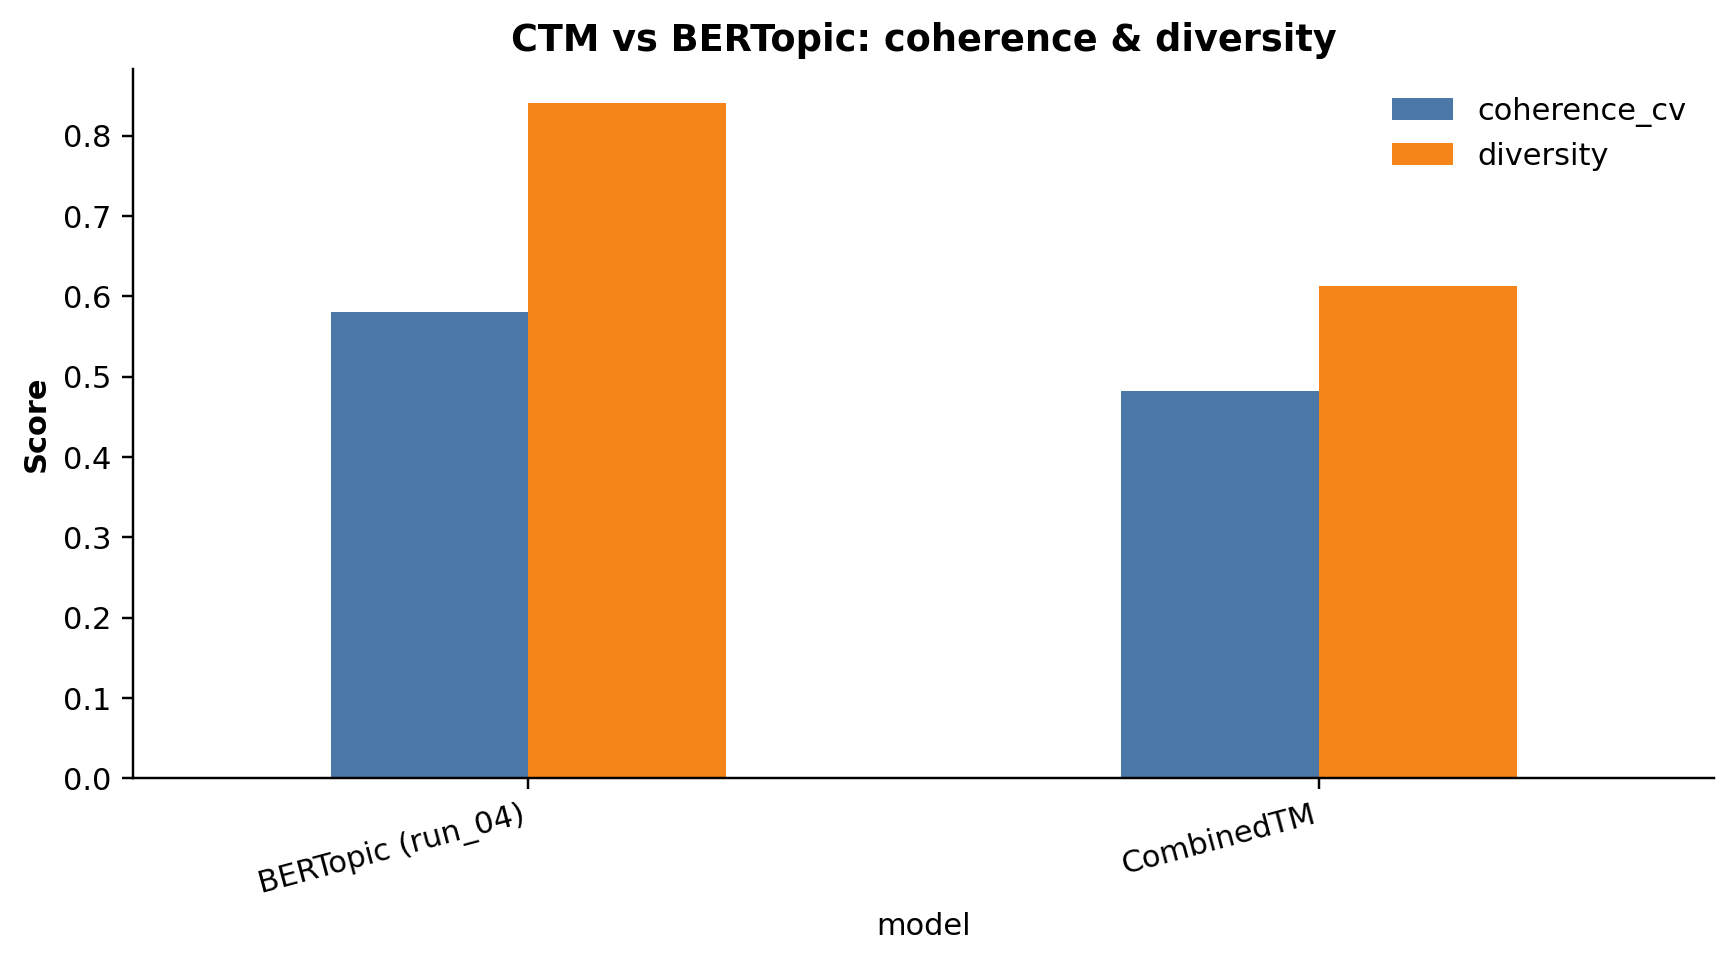

In [11]:
# Model-level quality: coherence & diversity
display(Image(FIG['ctm'] / 'fig1_ctm_vs_bertopic_metrics.png', width=700))

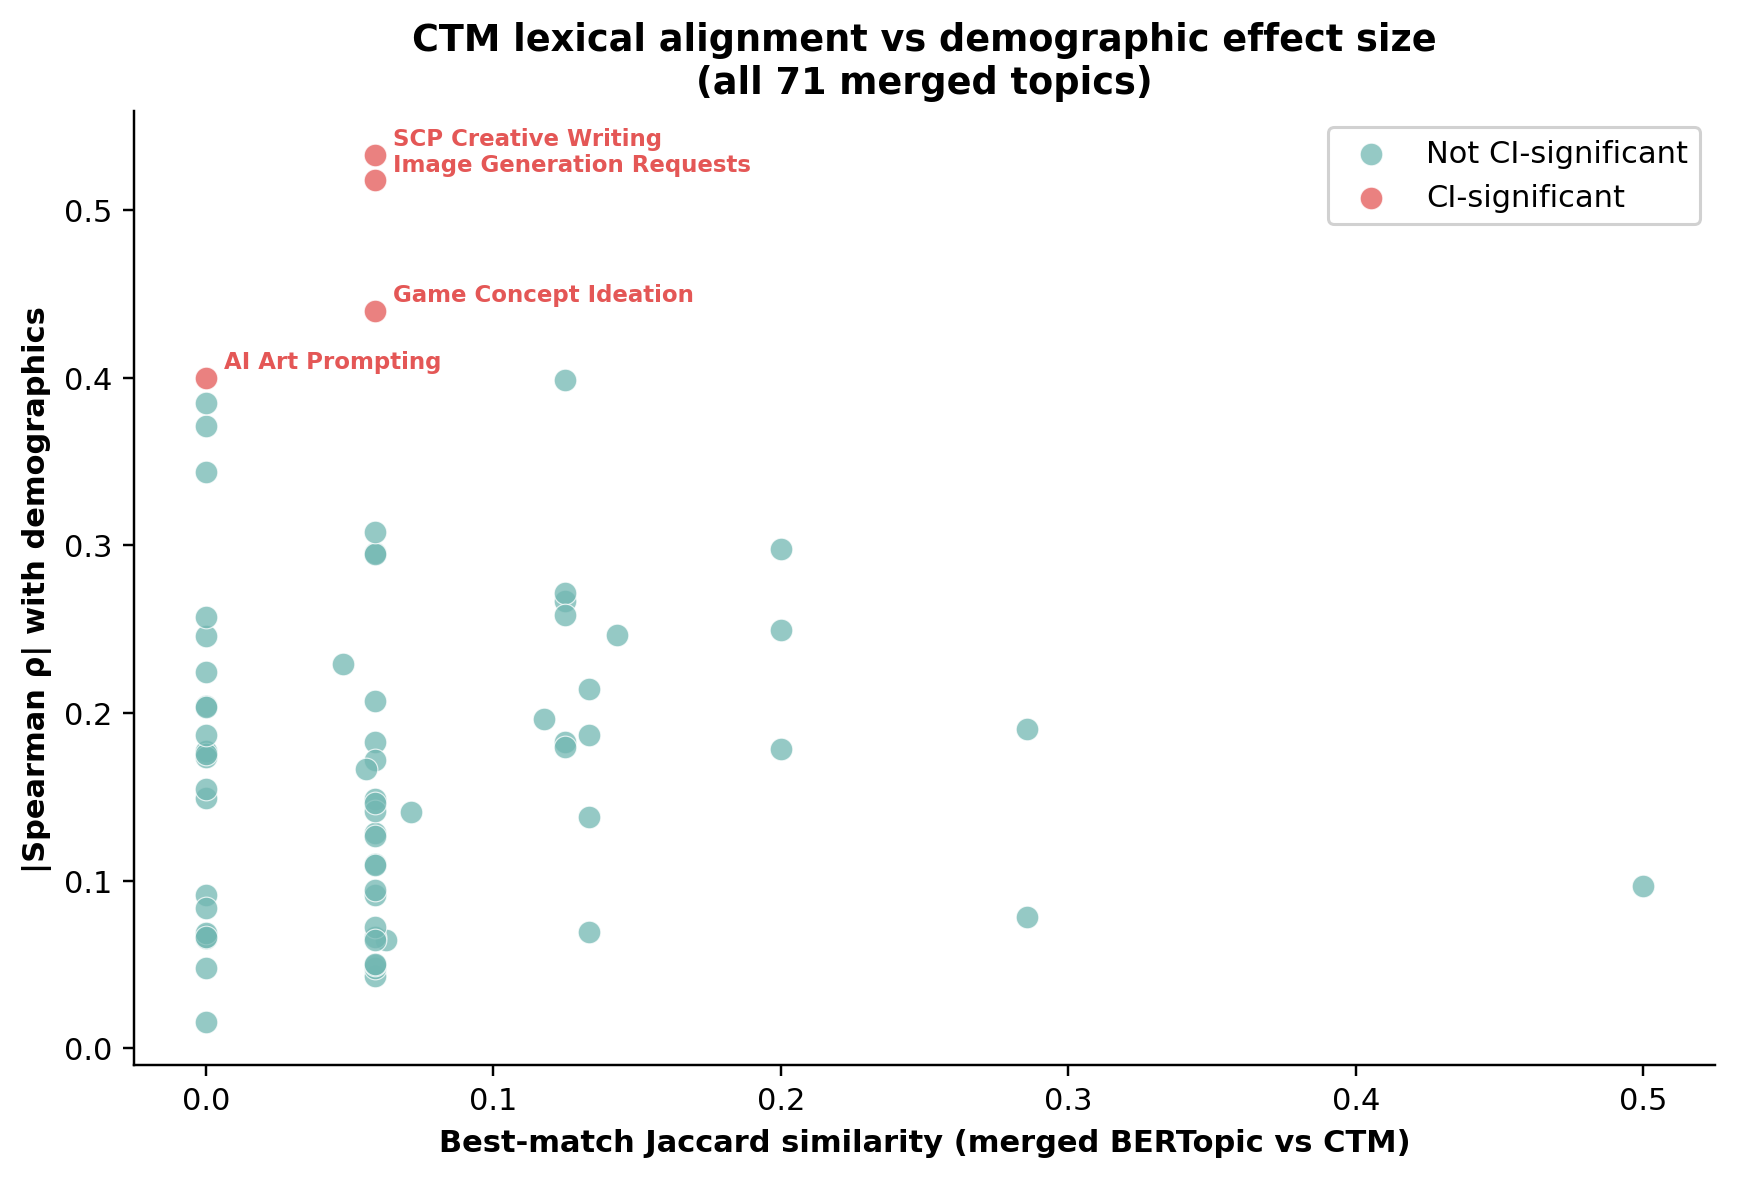

In [12]:
# |ρ| vs Jaccard scatter — CI-significant topics cluster at bottom
display(Image(FIG['ctm'] / 'fig2_alignment_vs_effect_size.png', width=800))

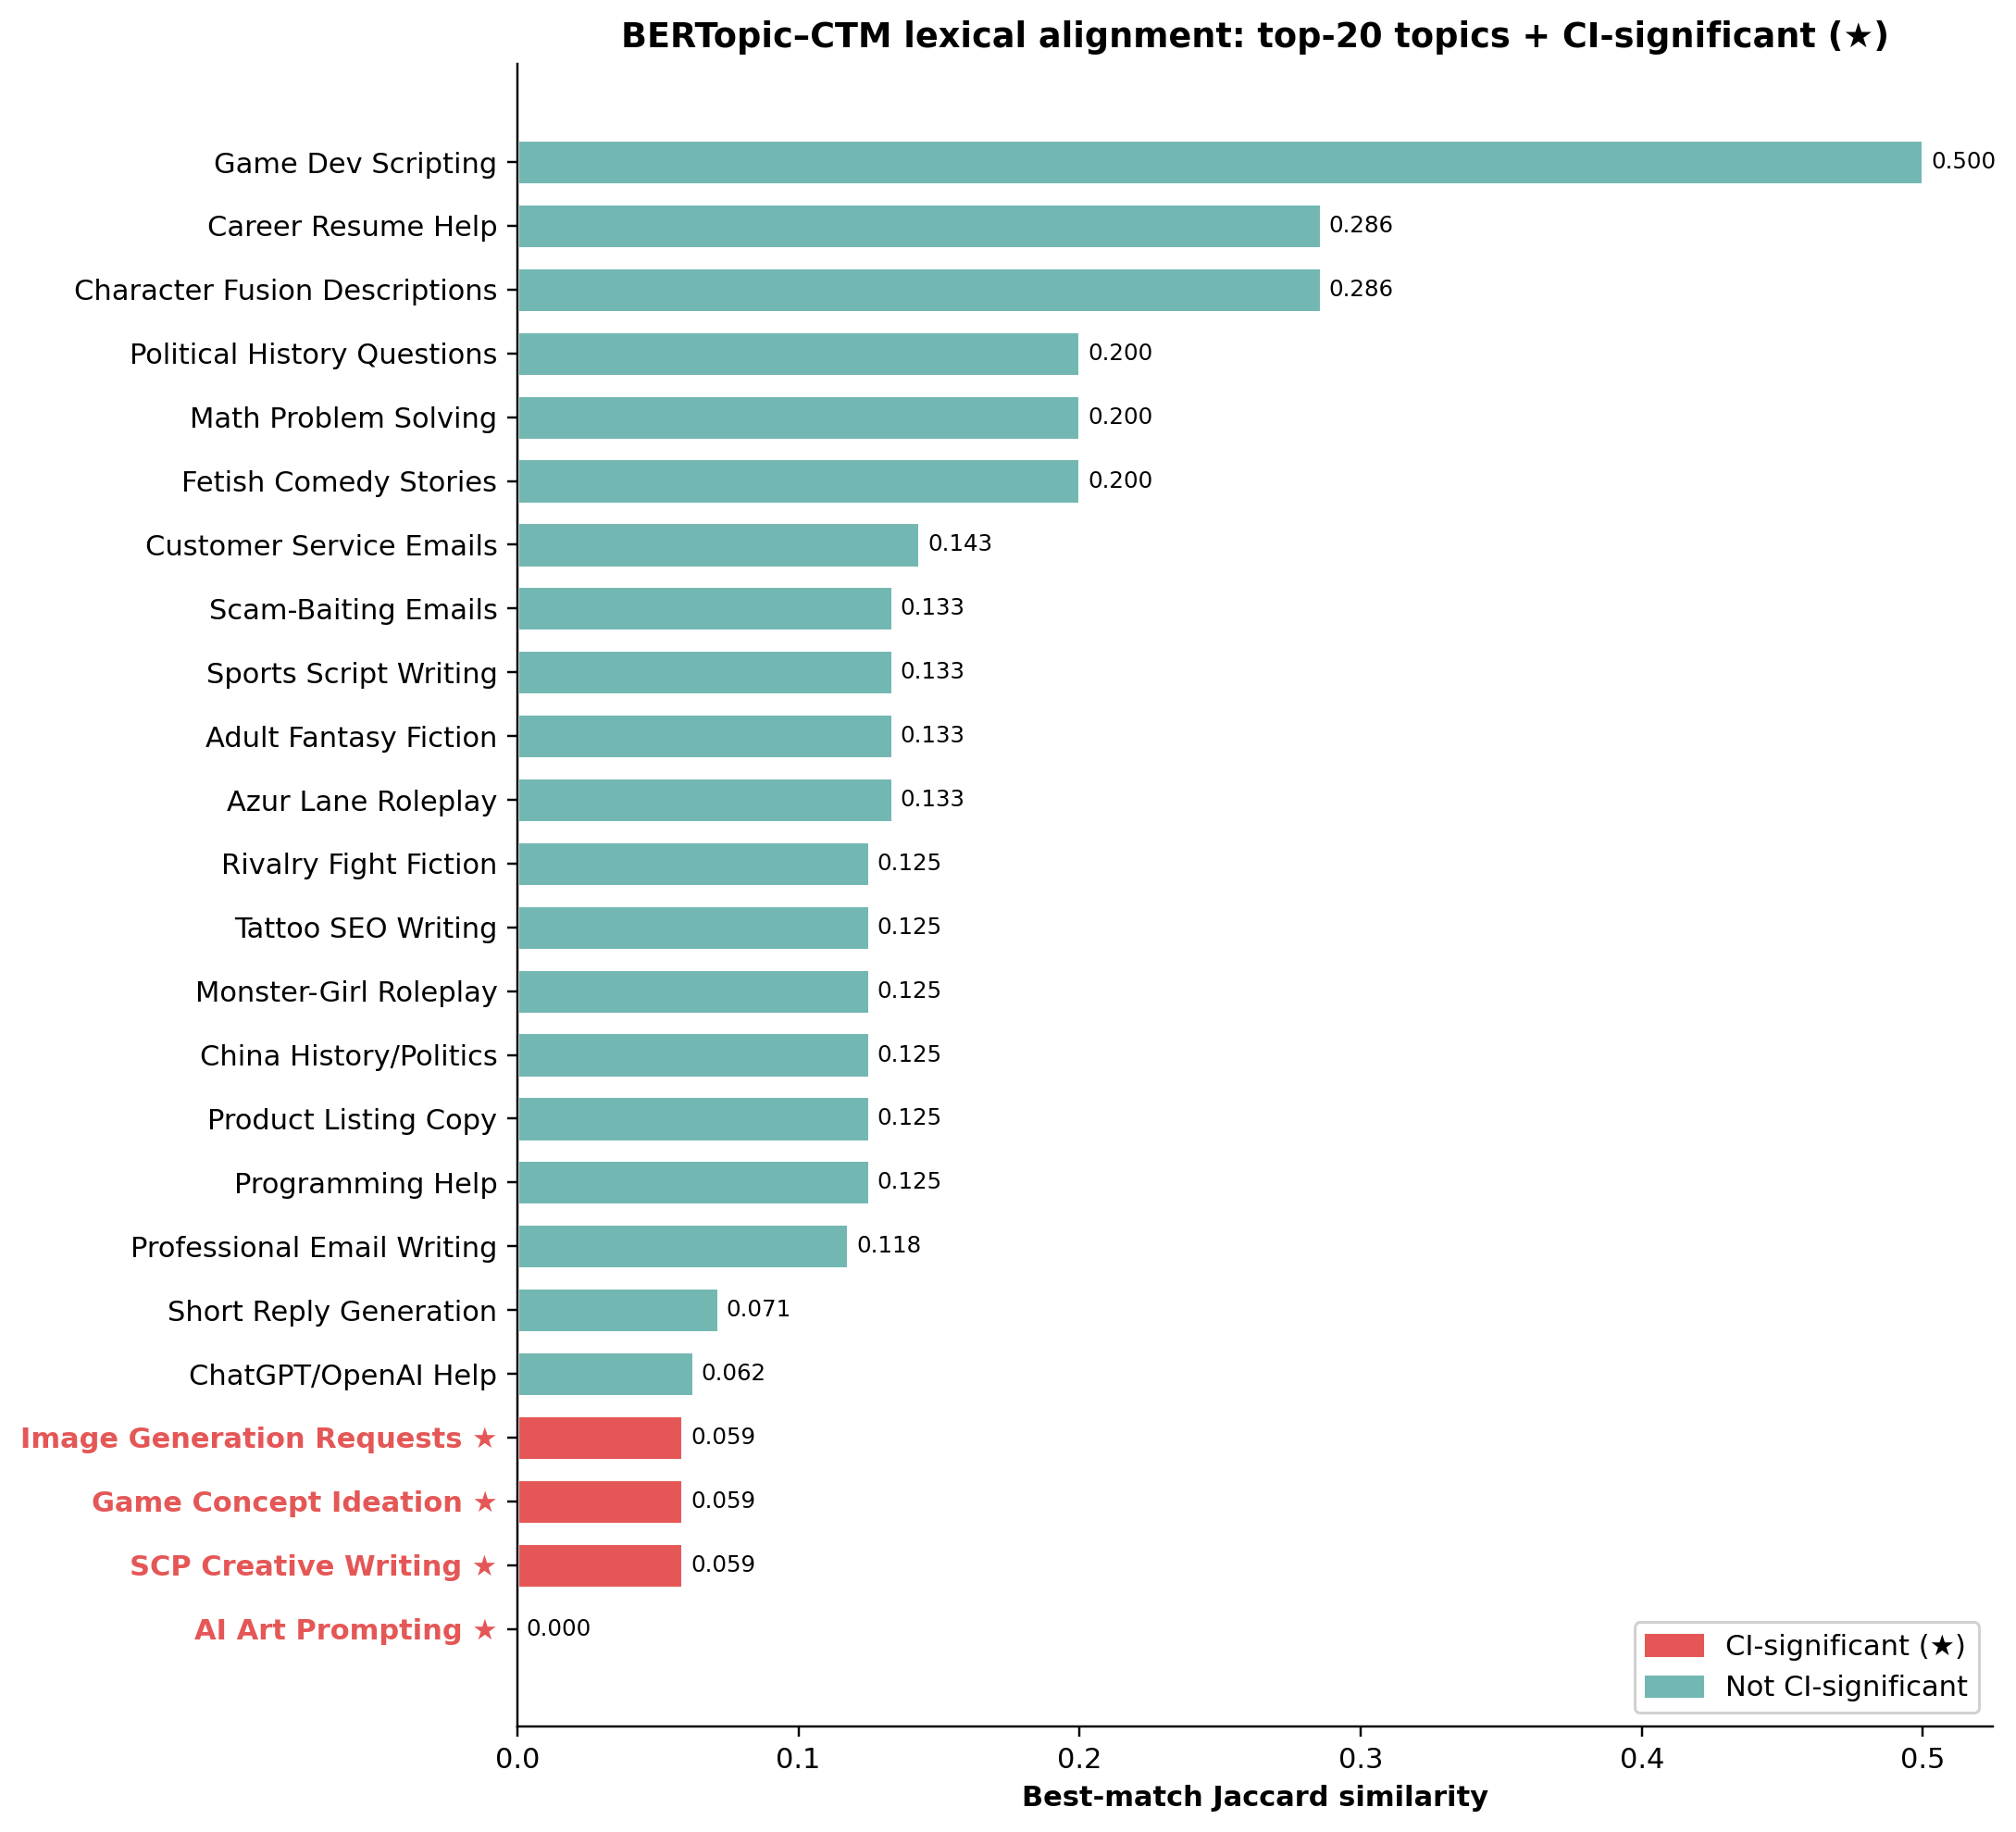

In [13]:
# Full Jaccard ranking across all 71 merged topics
display(Image(FIG['ctm'] / 'fig3_full_jaccard_ranking.png', width=900))

---
## Overall Conclusions

| Finding | Evidence |
|---|---|
| BERTopic identifies 71 interpretable merged topics across 9 super-categories | Weighted prevalence figures, LLM labeling |
| 4 merged topics show reliable demographic signal (bootstrap CI excludes 0) | Spearman ρ, heatmaps, scatter plots |
| Signal is consistent across income and education, and cross-validated by log-odds | Log-odds figures, CI table |
| CTM does not reproduce the CI-significant topics due to its own quality limitations | Jaccard scatter, model metric comparison |
| BERTopic remains the appropriate primary model (coherence 0.58 vs 0.48, diversity 0.84 vs 0.61) | Model metric comparison |


### Research Questions

### RQ1: Do users in different US states exhibit systematically different topic distributions?

**Yes.** A binomial null model applied to all 76 raw BERTopics finds significant cross-state dispersion for every topic (FDR $q = 0.0002$). 
Topic distributions are not random across states; they vary in structured, non-uniform ways.

### RQ2: Do state-level topic patterns correlate with demographic factors?

**Yes.** Four merged topics show reliable correlations (95% bootstrap CI excludes zero): 
SCP Creative Writing and Image Generation Requests are significant for both covariates; 
AI Art Prompting and Game Concept Ideation for income and education respectively.

### Hypotheses

### H1 — Topic distributions vary systematically across states
All 76 raw BERTopics pass a binomial null significance test for cross-state dispersion (FDR $q = 0.0002$).

### H2a — Variation reflects lower- vs higher-complexity task use
The CI-significant topics reveal a *niche creative vs. mass-use* split: 
higher-income/education states disproportionately use ChatGPT for SCP creative writing and AI art prompting, 
while image generation requests are more prevalent in lower-income states. 
The signal is better described as *creative specialization* rather than task complexity per state.

### H2b — Higher income → more productivity-oriented, technically complex uses
Higher-income states show more *creative niche* use (SCP writing, AI art prompting), not professional productivity tasks. 
Image generation requests — the more generic, lower-barrier use — are negatively correlated with income ($ \rho = -0.43$). 
The specialization is creative rather than professional.
